<a href="https://colab.research.google.com/github/d2021101420/PCO213/blob/main/PCO213_Treinam03_MAA%2BHL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

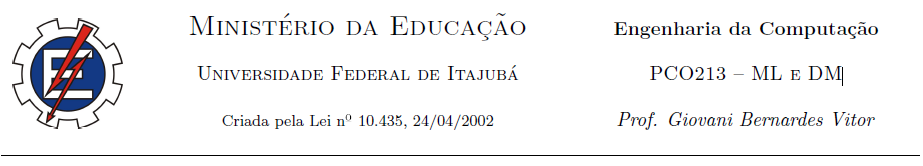

# Treinamento #3

**Observações:**

- Os códigos bem como as respostas textuais deverão ser enviados de maneira conjunta no arquivo com extensão .ipynb.
- Os demais arquivos, por exemplo, datasets podem ser enviados em formato compactado (.rar, .zip, etc.)
- Não serão aceitos o envio de arquivo no formato PDF ou DOC como resposta para o desenvolvimento das atividades.
- As atividades podem ser realizadas em grupos de no máximo 4 integrantes onde somente 1 deles será responsável pelo envio e postagem no SIGAA.
- Não serão aceitos a entrega das atividades fora do prazo e somente via SIGAA. Entregas via email não serão contabilizadas.
- Alguns exercícios exigem pesquisa extra-classe para cobrir todo o entendimento e conteúdo abordado neste treinamento.

### Matrícula e nome completo: *11.45.07 (UFOP) - HEBERT FERRAZ SOUZA LIMA*
### Matrícula e nome completo: *2026102180 - MAURÍCIO ANDRÉ DE ALMEIDA*

##
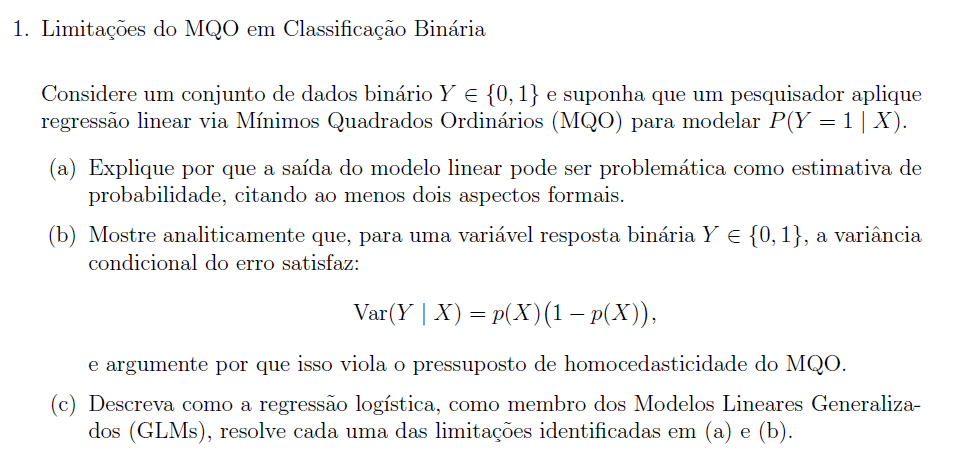

## RESPOSTAS:

### 1(a) — Por que a saída do modelo linear é problemática como estimativa de probabilidade?

O modelo de **Probabilidade Linear (MQO)** estima $P(Y=1|X) = \beta_0 + \beta_1 X$. Dois problemas formais centrais:

1. **Violação do suporte probabilístico:** Uma probabilidade deve satisfazer $P \in [0, 1]$ para todo $x$. O modelo linear não impõe essa restrição: $\hat{y} = \mathbf{w}^T\mathbf{x} + b$ pode assumir qualquer valor em $(-\infty, +\infty)$. Para valores extremos de $x$, teremos previsões negativas ou maiores que 1, o que não possui interpretação probabilística válida.

2. **Heterocedasticidade estrutural:** O MQO assume $\text{Var}(\varepsilon | X) = \sigma^2$ (constante). Porém, para $Y \in \{0,1\}$, a variância condicional depende de $x$ — veja a demonstração em (b). Essa heteroscedasticidade viola o Teorema de Gauss-Markov, tornando os estimadores MQO ineficientes (não-BLUE) e os erros-padrão incorretos, invalidando testes de hipótese e intervalos de confiança.

### 1(b) — Derivação de Var(Y | X) = p(X)(1 − p(X))

Para $Y \in \{0, 1\}$ com $P(Y=1|X) = p(X)$ e $P(Y=0|X) = 1-p(X)$:

**Esperança condicional:**
$$E[Y | X] = 1 \cdot p(X) + 0 \cdot (1 - p(X)) = p(X)$$

**Segundo momento condicional:**
$$E[Y^2 | X] = 1^2 \cdot p(X) + 0^2 \cdot (1 - p(X)) = p(X)$$

(pois $Y^2 = Y$ para $Y \in \{0,1\}$)

**Variância condicional (pela fórmula $\text{Var} = E[Y^2] - (E[Y])^2$):**
$$\text{Var}(Y|X) = E[Y^2|X] - (E[Y|X])^2 = p(X) - p(X)^2 = p(X)\bigl(1 - p(X)\bigr)$$

**Violação da homocedasticidade:** A variância $p(X)(1-p(X))$ é uma função de $x$ — ela é máxima quando $p(X) = 0{,}5$ e tende a zero quando $p(X) \to 0$ ou $p(X) \to 1$. Portanto, a variância dos erros **não é constante**, violando o pressuposto de homocedasticidade do MQO.

### 1(c) — Como a Regressão Logística (GLM) resolve essas limitações

A regressão logística é um **Modelo Linear Generalizado (GLM)** com:

- **Componente aleatório:** distribuição de Bernoulli → resolve o problema da heterocedasticidade ao modelar explicitamente a distribuição correta de $Y$.
- **Função de ligação:** logit $g(\mu) = \log\frac{\mu}{1-\mu}$, cuja inversa é a sigmoide:
$$\hat{y} = \sigma(\mathbf{w}^T\mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T\mathbf{x} + b)}} \in (0, 1)$$

**Resolução das limitações:**
1. *Suporte inválido:* A sigmoide garante $\hat{y} \in (0,1)$ para qualquer valor do preditor linear, tornando a saída uma probabilidade bem-definida.
2. *Heterocedasticidade:* Em vez de minimizar resíduos com variância constante, o GLM usa **Máxima Verossimilhança (MLE)** com a função de verossimilhança Bernoulli, que já incorpora a variância heterocedástica $p(1-p)$ como parte do modelo — não como uma violação.

##
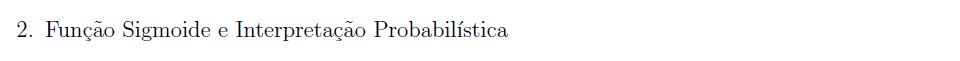

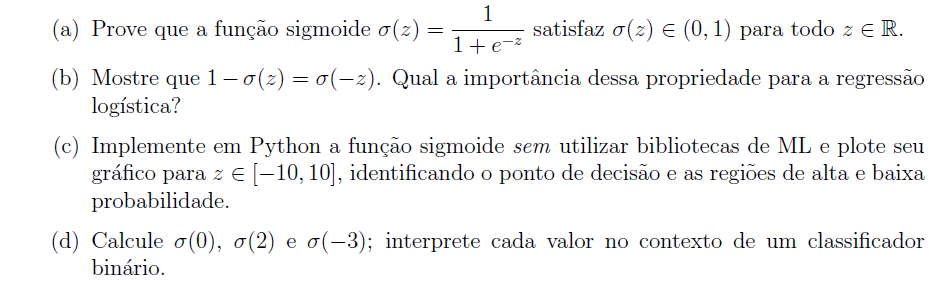

## RESPOSTAS:

### 2(a) — Prova que σ(z) ∈ (0, 1) para todo z ∈ ℝ

Defina $\sigma(z) = \dfrac{1}{1 + e^{-z}}$.

**Limite inferior:** Para qualquer $z \in \mathbb{R}$, temos $e^{-z} > 0$, logo $1 + e^{-z} > 1 > 0$. Portanto:
$$\sigma(z) = \frac{1}{1 + e^{-z}} > 0$$

**Limite superior:** Como $e^{-z} > 0$, temos $1 + e^{-z} > 1$, logo:
$$\sigma(z) = \frac{1}{1 + e^{-z}} < \frac{1}{1} = 1$$

Os extremos nunca são atingidos:
- $\lim_{z \to +\infty} \sigma(z) = \frac{1}{1+0} = 1$ (limite, não valor atingido)
- $\lim_{z \to -\infty} \sigma(z) = \frac{1}{1+\infty} = 0$ (limite, não valor atingido)

Portanto, $\sigma(z) \in (0, 1)$ para todo $z \in \mathbb{R}$. $\blacksquare$

### 2(b) — Prova que 1 − σ(z) = σ(−z)

$$1 - \sigma(z) = 1 - \frac{1}{1+e^{-z}} = \frac{1+e^{-z}-1}{1+e^{-z}} = \frac{e^{-z}}{1+e^{-z}}$$

Multiplicando numerador e denominador por $e^{z}$:

$$= \frac{e^{-z} \cdot e^{z}}{(1+e^{-z}) \cdot e^{z}} = \frac{1}{e^{z}+1} = \frac{1}{1+e^{-(-z)}} = \sigma(-z) \quad \blacksquare$$

**Importância na regressão logística:** Esta propriedade garante **simetria** no modelo. A probabilidade de $Y=0$ dado $x$ é exatamente $\sigma(-\mathbf{w}^T\mathbf{x})$, ou seja, usar o preditor negado. Isso simplifica a função de verossimilhança e permite escrever:
$$P(Y=y|x) = \sigma(z)^y \cdot \sigma(-z)^{1-y}$$
em uma única expressão elegante.

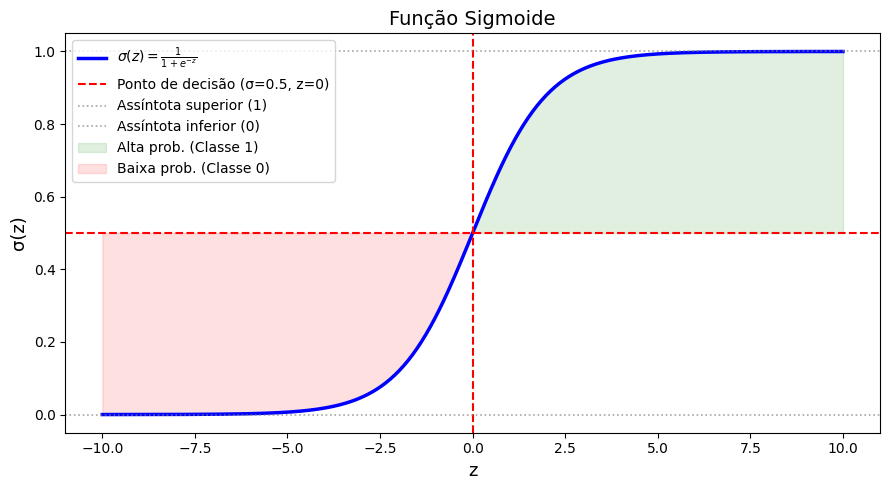

In [1]:
# 2(c) — Implementação da sigmoide e gráfico
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Função sigmoide implementada sem bibliotecas de ML."""
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-10, 10, 500)
sigma = sigmoid(z)

plt.figure(figsize=(9, 5))
plt.plot(z, sigma, 'b-', linewidth=2.5, label=r'$\sigma(z) = \frac{1}{1+e^{-z}}$')
plt.axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Ponto de decisão (σ=0.5, z=0)')
plt.axvline(0, color='red', linestyle='--', linewidth=1.5)
plt.axhline(1.0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='Assíntota superior (1)')
plt.axhline(0.0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7, label='Assíntota inferior (0)')

# Regiões
plt.fill_between(z, sigma, 0.5, where=(sigma > 0.5), alpha=0.12, color='green', label='Alta prob. (Classe 1)')
plt.fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.12, color='red', label='Baixa prob. (Classe 0)')

plt.xlabel('z', fontsize=13)
plt.ylabel('σ(z)', fontsize=13)
plt.title('Função Sigmoide', fontsize=14)
plt.legend(fontsize=10)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('sigmoide.png', dpi=150)
plt.show()

In [2]:
# 2(d) — Cálculo e interpretação de σ(0), σ(2), σ(-3)

valores = {0: sigmoid(0), 2: sigmoid(2), -3: sigmoid(-3)}

for z_val, s_val in valores.items():
    print(f'σ({z_val:2d}) = {s_val:.4f}')

print()
print('Interpretações:')
print(f'  σ(0)  = {sigmoid(0):.4f} → Preditor linear nulo: probabilidade exatamente 0.5 (máxima incerteza).')
print(f'  σ(2)  = {sigmoid(2):.4f} → Preditor positivo moderado: ~88% de chance de ser Classe 1.')
print(f'  σ(-3) = {sigmoid(-3):.4f} → Preditor negativo forte: ~5% de chance de ser Classe 1 (modelo confiante em Classe 0).')

σ( 0) = 0.5000
σ( 2) = 0.8808
σ(-3) = 0.0474

Interpretações:
  σ(0)  = 0.5000 → Preditor linear nulo: probabilidade exatamente 0.5 (máxima incerteza).
  σ(2)  = 0.8808 → Preditor positivo moderado: ~88% de chance de ser Classe 1.
  σ(-3) = 0.0474 → Preditor negativo forte: ~5% de chance de ser Classe 1 (modelo confiante em Classe 0).


##
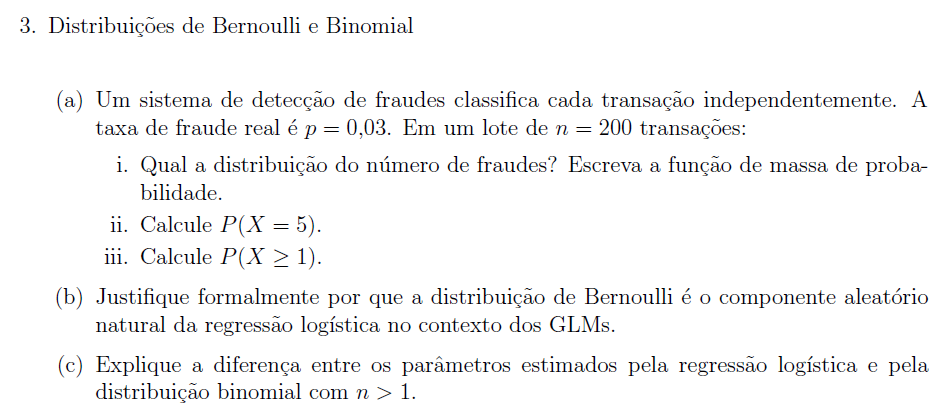

## RESPOSTAS:

**(3) i. Distribuição do número de fraudes:**

Cada transação é classificada independentemente com probabilidade de fraude $p = 0{,}03$. O número total de fraudes $X$ em $n = 200$ transações segue uma distribuição **Binomial**:

$$X \sim \text{Binomial}(n=200,\ p=0{,}03)$$

**Função de Massa de Probabilidade (PMF):**

$$P(X = k) = \binom{200}{k} (0{,}03)^k (0{,}97)^{200-k}, \quad k = 0, 1, 2, \ldots, 200$$

P(X = 5) = 0.162250
P(X >= 1) = 1 - P(X=0) = 1 - 0.002261 = 0.997739


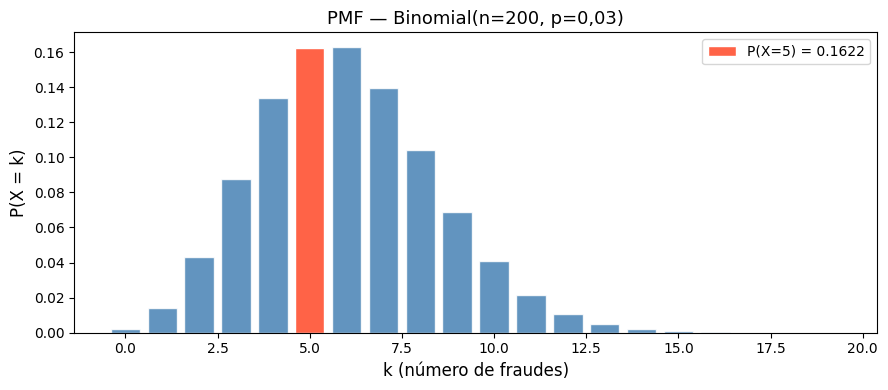

In [3]:
# 3(a) ii e iii — Cálculos com distribuição binomial
from scipy.stats import binom
import numpy as np
import matplotlib.pyplot as plt



n, p = 200, 0.03

# ii. P(X = 5)
prob_x5 = binom.pmf(5, n, p)
print(f'P(X = 5) = {prob_x5:.6f}')

# iii. P(X >= 1) = 1 - P(X = 0)
prob_x_geq_1 = 1 - binom.pmf(0, n, p)
print(f'P(X >= 1) = 1 - P(X=0) = 1 - {binom.pmf(0,n,p):.6f} = {prob_x_geq_1:.6f}')

# Visualização da PMF
k_vals = np.arange(0, 20)
probs = binom.pmf(k_vals, n, p)

plt.figure(figsize=(9, 4))
plt.bar(k_vals, probs, color='steelblue', edgecolor='white', alpha=0.85)
plt.bar(5, prob_x5, color='tomato', edgecolor='white', label=f'P(X=5) = {prob_x5:.4f}')
plt.xlabel('k (número de fraudes)', fontsize=12)
plt.ylabel('P(X = k)', fontsize=12)
plt.title('PMF — Binomial(n=200, p=0,03)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

### 3(b) — Por que Bernoulli é o componente aleatório natural dos GLMs na regressão logística

Em um GLM, o **componente aleatório** define a distribuição da variável resposta $Y|X$. Para classificação binária $Y \in \{0, 1\}$, a distribuição natural é a **Bernoulli** com parâmetro $\mu = p(x) = P(Y=1|X=x)$:

$$P(Y=y|X) = p(x)^y (1-p(x))^{1-y}, \quad y \in \{0,1\}$$

A Bernoulli pertence à **família exponencial**, que é o requisito formal dos GLMs. Sua log-verossimilhança é côncava, garantindo que o MLE seja único e computacionalmente tratável. A função de ligação **canônica** associada à Bernoulli é exatamente o **logit**: $g(\mu) = \log\frac{\mu}{1-\mu}$, cujo inverso é a sigmoide. Essa correspondência não é coincidência — emerge naturalmente da estrutura da família exponencial.

### 3(c) — Diferença entre parâmetros estimados pela regressão logística e pela Binomial com n > 1

| Aspecto | Regressão Logística | Binomial(n > 1) |
|---|---|---|
| **Observação** | Par $(x^{(i)}, y^{(i)})$ com $y^{(i)} \in \{0,1\}$ | Contagem $k$ de sucessos em $n$ tentativas |
| **Parâmetros estimados** | $\mathbf{w}$ e $b$ (coeficientes do preditor linear) | $p$ (único parâmetro de probabilidade) |
| **Dependência em x** | $p = \sigma(\mathbf{w}^Tx+b)$ varia com $x$ | $p$ é global, fixo para todo $n$ |
| **Flexibilidade** | Alta — modela probabilidades condicionais distintas por observação | Baixa — assume mesma $p$ para todas as tentativas |

Em síntese: a regressão logística estima como $p$ varia com as covariáveis $x$, enquanto a Binomial simples estima um valor único de $p$ a partir de $n$ ensaios repetidos nas mesmas condições.

##
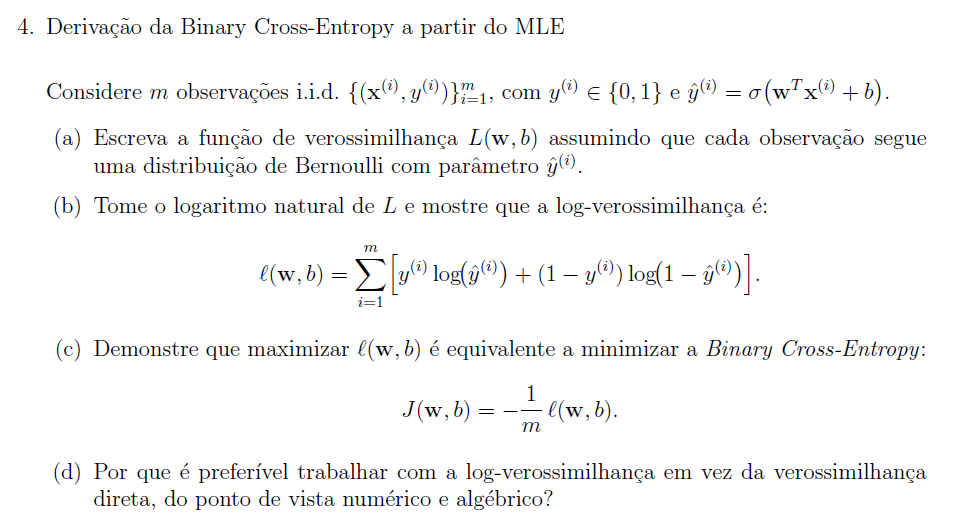

## RESPOSTAS:

### 4(a) — Função de Verossimilhança L(w, b)

Assumindo que cada observação $(x^{(i)}, y^{(i)})$ é i.i.d. com distribuição Bernoulli de parâmetro $\hat{y}^{(i)} = \sigma(\mathbf{w}^T x^{(i)} + b)$:

$$P(y^{(i)} | x^{(i)}; \mathbf{w}, b) = \hat{y}^{(i)^{y^{(i)}}} \cdot (1 - \hat{y}^{(i)})^{1-y^{(i)}}$$

Pela hipótese de independência, a verossimilhança conjunta é o produto:

$$L(\mathbf{w}, b) = \prod_{i=1}^{m} \hat{y}^{(i)^{y^{(i)}}} \cdot (1 - \hat{y}^{(i)})^{1-y^{(i)}}$$

### 4(b) — Log-verossimilhança ℓ(w, b)

Aplicando o logaritmo natural (função monotônica crescente, portanto maximizar $L$ ↔ maximizar $\ell$):

$$\ell(\mathbf{w}, b) = \log L(\mathbf{w}, b) = \sum_{i=1}^{m} \log\left[\hat{y}^{(i)^{y^{(i)}}} \cdot (1 - \hat{y}^{(i)})^{1-y^{(i)}}\right]$$

Usando propriedades do logaritmo ($\log(a \cdot b) = \log a + \log b$ e $\log(a^k) = k \log a$):

$$\boxed{\ell(\mathbf{w}, b) = \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]}$$

### 4(c) — Equivalência entre maximizar ℓ e minimizar a BCE

Defina a **Binary Cross-Entropy (BCE)**:

$$J(\mathbf{w}, b) = -\frac{1}{m} \ell(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log \hat{y}^{(i)} + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Como $J = -\frac{1}{m}\ell$ e $\frac{1}{m} > 0$, temos:

$$\underset{\mathbf{w},b}{\arg\max}\; \ell(\mathbf{w},b) = \underset{\mathbf{w},b}{\arg\min}\; J(\mathbf{w},b)$$

O fator $\frac{1}{m}$ é apenas uma normalização (escala) que não altera o ponto ótimo, mas estabiliza a magnitude do gradiente em relação ao tamanho do dataset. $\blacksquare$

### 4(d) — Por que usar log-verossimilhança em vez de verossimilhança direta?

1. **Estabilidade numérica:** O produto de $m$ probabilidades $\in (0,1)$ converge rapidamente para zero quando $m$ cresce, causando **underflow** de ponto flutuante. O logaritmo transforma o produto em soma, mantendo os valores em faixa computável.

2. **Simplicidade algébrica:** O logaritmo desfaz os produtos em somas e as potências em multiplicações lineares, tornando os cálculos de gradiente analíticos muito mais simples (como demonstrado em Q5).

3. **Convexidade preservada:** $\log$ é função côncava crescente, e a composição $\log \circ \sigma$ aplicada à verossimilhança Bernoulli resulta em uma função côncava nos parâmetros, o que garante convergência do gradiente ascendente para o máximo global.

##
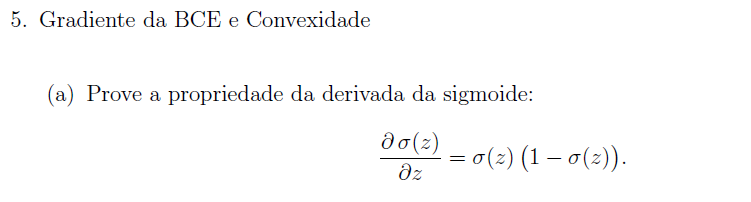

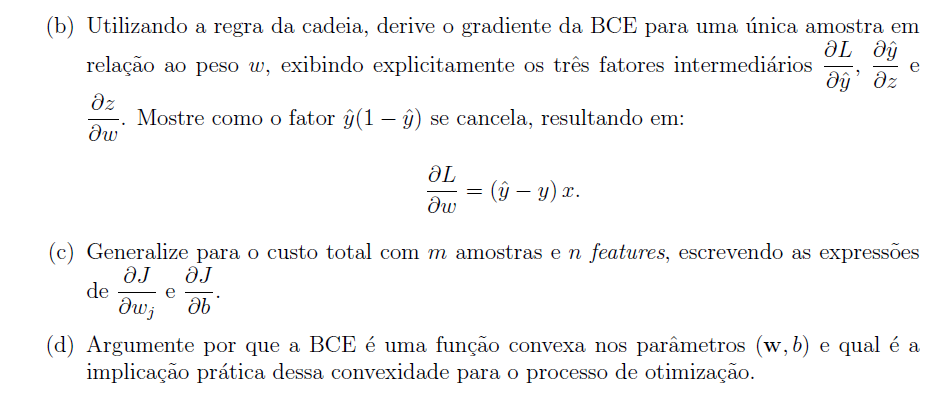

## RESPOSTAS:

### 5(a) — Prova da derivada da sigmoide: σ'(z) = σ(z)(1 − σ(z))

Seja $\sigma(z) = (1 + e^{-z})^{-1}$. Pela **regra do quociente** (ou regra da cadeia):

$$\frac{\partial \sigma}{\partial z} = \frac{\partial}{\partial z}\left(1 + e^{-z}\right)^{-1} = -1 \cdot \left(1 + e^{-z}\right)^{-2} \cdot (-e^{-z}) = \frac{e^{-z}}{(1 + e^{-z})^2}$$

Reescrevendo:

$$= \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z) \cdot \frac{e^{-z}}{1+e^{-z}}$$

Usando $1 - \sigma(z) = \frac{e^{-z}}{1+e^{-z}}$ (demonstrado em Q2(b)):

$$\boxed{\frac{\partial \sigma(z)}{\partial z} = \sigma(z)\bigl(1 - \sigma(z)\bigr)} \quad \blacksquare$$

### 5(b) — Derivação do gradiente da BCE para uma única amostra

Para uma amostra, a perda é $L = -\left[y \log \hat{y} + (1-y)\log(1-\hat{y})\right]$, com $\hat{y} = \sigma(z)$ e $z = \mathbf{w}^Tx + b$.

Pela **regra da cadeia**: $\dfrac{\partial L}{\partial w} = \dfrac{\partial L}{\partial \hat{y}} \cdot \dfrac{\partial \hat{y}}{\partial z} \cdot \dfrac{\partial z}{\partial w}$

**Fator 1 — $\partial L / \partial \hat{y}$:**
$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}} = \frac{-y(1-\hat{y}) + (1-y)\hat{y}}{\hat{y}(1-\hat{y})} = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}$$

**Fator 2 — $\partial \hat{y} / \partial z$:**
$$\frac{\partial \hat{y}}{\partial z} = \sigma(z)(1-\sigma(z)) = \hat{y}(1-\hat{y})$$

**Fator 3 — $\partial z / \partial w$:**
$$\frac{\partial z}{\partial w} = x$$

**Produto (cancelamento de $\hat{y}(1-\hat{y})$):**
$$\frac{\partial L}{\partial w} = \frac{\hat{y}-y}{\hat{y}(1-\hat{y})} \cdot \hat{y}(1-\hat{y}) \cdot x = \boxed{(\hat{y} - y)\, x} \quad \blacksquare$$

### 5(c) — Gradiente para m amostras e n features

Generalizando para o custo total $J(\mathbf{w}, b) = -\frac{1}{m}\ell$:

$$\boxed{\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right) x_j^{(i)}, \quad j = 1, \ldots, n}$$

$$\boxed{\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)}$$

Em notação matricial compacta (com $X \in \mathbb{R}^{m \times n}$ e $\hat{y}, y \in \mathbb{R}^m$):
$$\nabla_\mathbf{w} J = \frac{1}{m} X^T(\hat{\mathbf{y}} - \mathbf{y}), \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\mathbf{1}^T(\hat{\mathbf{y}} - \mathbf{y})$$

### 5(d) — Por que a BCE é convexa e implicação prática

**Convexidade:** A BCE é convexa nos parâmetros $(\mathbf{w}, b)$ porque:
- $\log \sigma(z)$ é côncava em $z$, e $z = \mathbf{w}^Tx+b$ é linear em $\mathbf{w}$;
- A composição de funções côncavas com funções afins é côncava;
- A BCE é $-\frac{1}{m}\ell$, negativo de côncava = convexa.

Formalmente, a Hessiana $H = \frac{1}{m}X^T \text{diag}(\hat{y}(1-\hat{y})) X$ é semidefinida positiva (pois $\hat{y}(1-\hat{y}) > 0$ e a forma quadrática é positiva).

**Implicação prática:** Em uma função convexa, **qualquer mínimo local é também o mínimo global**. Isso garante que o gradiente descendente (com taxa de aprendizado adequada) sempre converge para a solução ótima global, independentemente da inicialização dos parâmetros.

###
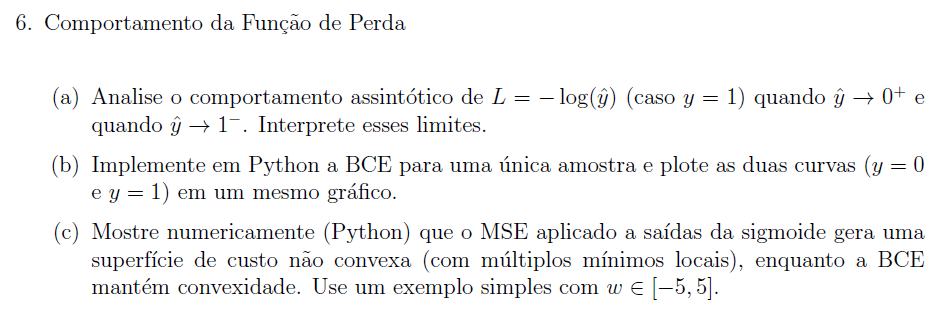

## RESPOSTAS:

### 6(a) — Análise assintótica de L = −log(ŷ) quando y = 1

Para $y = 1$, a perda é $L = -\log(\hat{y})$:

- **$\hat{y} \to 0^+$:** $L = -\log(\hat{y}) \to +\infty$ — O modelo prevê probabilidade zero para a classe verdadeira. A penalidade é **infinita**, refletindo que errar completamente é catastrófico.

- **$\hat{y} \to 1^-$:** $L = -\log(\hat{y}) \to 0^+$ — O modelo prevê probabilidade próxima de 1 para a classe correta. A penalidade tende a **zero**, indicando previsão perfeita.

Essa assimetria é desejável: o modelo é incentivado a ser confiante nas previsões corretas e penalizado severamente por previsões confiantes erradas.

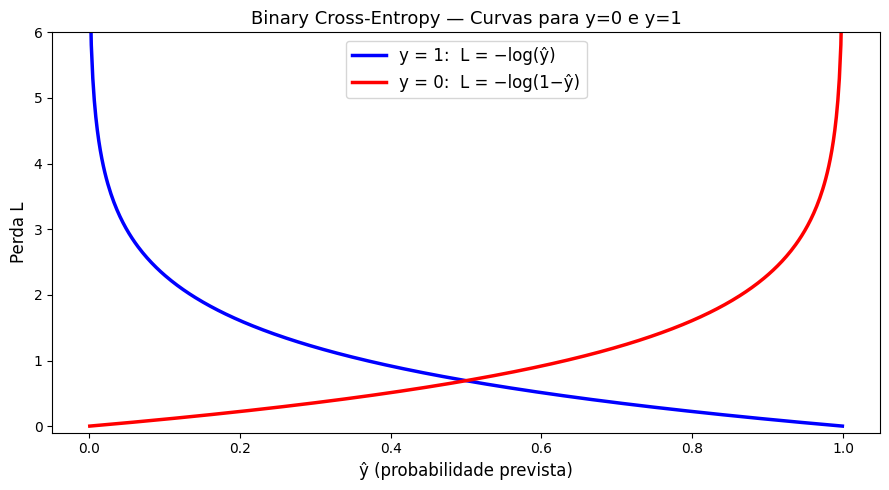

In [4]:
# 6(b) — Implementação da BCE e gráfico das duas curvas

def bce_y1(y_hat):
    """BCE para y=1: L = -log(y_hat)"""
    return -np.log(y_hat + 1e-15)

def bce_y0(y_hat):
    """BCE para y=0: L = -log(1 - y_hat)"""
    return -np.log(1 - y_hat + 1e-15)

y_hat_vals = np.linspace(0.001, 0.999, 500)

plt.figure(figsize=(9, 5))
plt.plot(y_hat_vals, bce_y1(y_hat_vals), 'b-', linewidth=2.5, label='y = 1:  L = −log(ŷ)')
plt.plot(y_hat_vals, bce_y0(y_hat_vals), 'r-', linewidth=2.5, label='y = 0:  L = −log(1−ŷ)')
plt.xlabel('ŷ (probabilidade prevista)', fontsize=12)
plt.ylabel('Perda L', fontsize=12)
plt.title('Binary Cross-Entropy — Curvas para y=0 e y=1', fontsize=13)
plt.legend(fontsize=12)
plt.ylim(-0.1, 6)
plt.tight_layout()
plt.savefig('bce_curves.png', dpi=150)
plt.show()

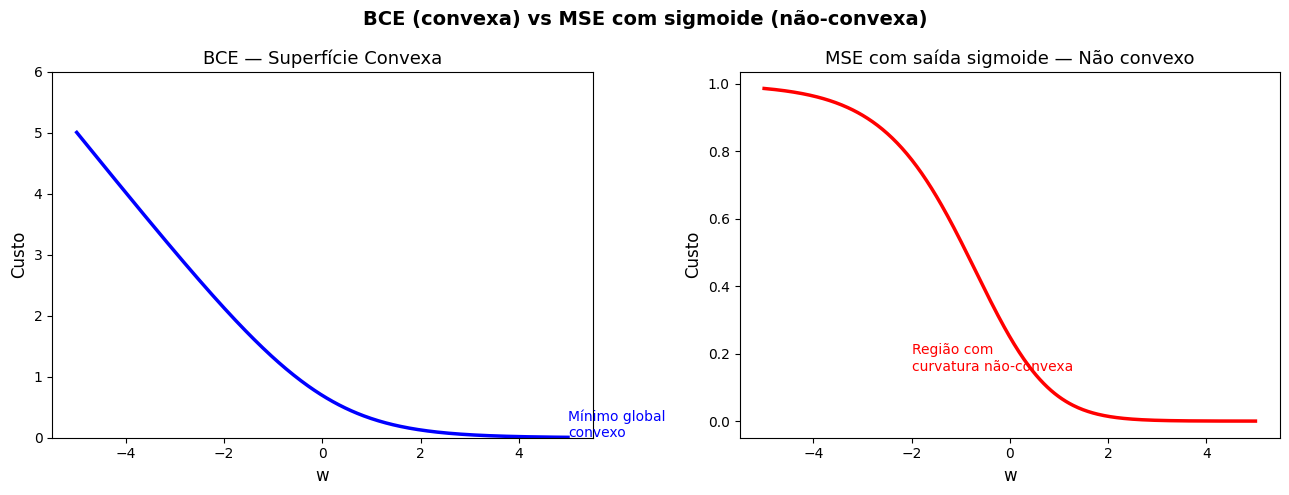

MSE com sigmoide pode apresentar região de gradiente muito pequeno (saturação),
gerando problemas práticos similares aos de múltiplos mínimos locais.


In [5]:
# 6(c) — MSE vs BCE: convexidade

np.random.seed(42)
x_demo = np.array([1.0])   # Feature fixa
y_demo = 1                  # Rótulo verdadeiro

w_range = np.linspace(-5, 5, 400)
b_fixed = 0.0

bce_costs = []
mse_costs = []

for w in w_range:
    y_hat = sigmoid(w * x_demo[0] + b_fixed)
    bce_costs.append(-( y_demo * np.log(y_hat + 1e-15) + (1-y_demo) * np.log(1-y_hat + 1e-15)))
    mse_costs.append((y_demo - y_hat)**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(w_range, bce_costs, 'b-', linewidth=2.5)
axes[0].set_title('BCE — Superfície Convexa', fontsize=13)
axes[0].set_xlabel('w', fontsize=12)
axes[0].set_ylabel('Custo', fontsize=12)
axes[0].set_ylim(0, 6)
axes[0].annotate('Mínimo global\nconvexo', xy=(5, min(bce_costs)), fontsize=10, color='blue')

axes[1].plot(w_range, mse_costs, 'r-', linewidth=2.5)
axes[1].set_title('MSE com saída sigmoide — Não convexo', fontsize=13)
axes[1].set_xlabel('w', fontsize=12)
axes[1].set_ylabel('Custo', fontsize=12)
axes[1].annotate('Região com\ncurvatura não-convexa', xy=(-2, 0.15), fontsize=10, color='red')

plt.suptitle('BCE (convexa) vs MSE com sigmoide (não-convexa)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('bce_vs_mse.png', dpi=150)
plt.show()

print('MSE com sigmoide pode apresentar região de gradiente muito pequeno (saturação),'
      '\ngerando problemas práticos similares aos de múltiplos mínimos locais.')

##
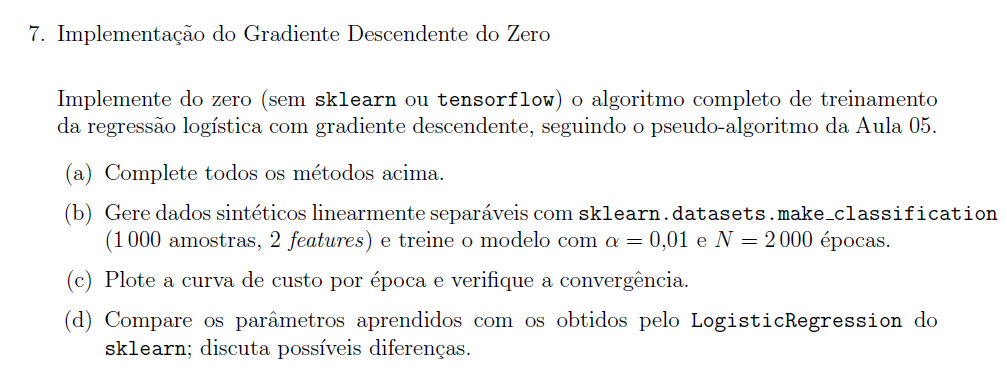

## RESPOSTAS:

In [6]:
class LogisticRegressionGD:
    """
    Regressão Logística com Gradiente Descendente implementada do zero.
    Sem uso de sklearn, tensorflow ou qualquer biblioteca de ML.
    """

    def __init__(self, alpha=0.01, n_epochs=1000):
        self.alpha = alpha         # Taxa de aprendizado
        self.n_epochs = n_epochs   # Número de épocas
        self.w = None              # Pesos
        self.b = None              # Bias
        self.cost_history = []     # Histórico de custo por época

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _compute_cost(self, y_hat, y):
        m = len(y)
        eps = 1e-15
        return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    def fit(self, X, y):
        m, n = X.shape
        # Inicialização com zeros
        self.w = np.zeros(n)
        self.b = 0.0
        self.cost_history = []

        for epoch in range(self.n_epochs):
            # Forward pass
            z = X @ self.w + self.b
            y_hat = self._sigmoid(z)

            # Custo
            cost = self._compute_cost(y_hat, y)
            self.cost_history.append(cost)

            # Gradientes
            error = y_hat - y
            dw = (X.T @ error) / m
            db = np.sum(error) / m

            # Atualização dos parâmetros
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)

print('Classe LogisticRegressionGD definida com sucesso.')

Classe LogisticRegressionGD definida com sucesso.


In [7]:
# 7(b) — Dados sintéticos e treinamento
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Padronização
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Treinamento do modelo próprio
model_gd = LogisticRegressionGD(alpha=0.01, n_epochs=2000)
model_gd.fit(X_train_sc, y_train)

acc_train = model_gd.accuracy(X_train_sc, y_train)
acc_test  = model_gd.accuracy(X_test_sc,  y_test)
print(f'Acurácia treino : {acc_train:.4f}')
print(f'Acurácia teste  : {acc_test:.4f}')
print(f'\nParâmetros aprendidos:')
print(f'  w = {model_gd.w}')
print(f'  b = {model_gd.b:.4f}')

Acurácia treino : 0.9012
Acurácia teste  : 0.8950

Parâmetros aprendidos:
  w = [-0.1099364   2.41087204]
  b = 0.0971


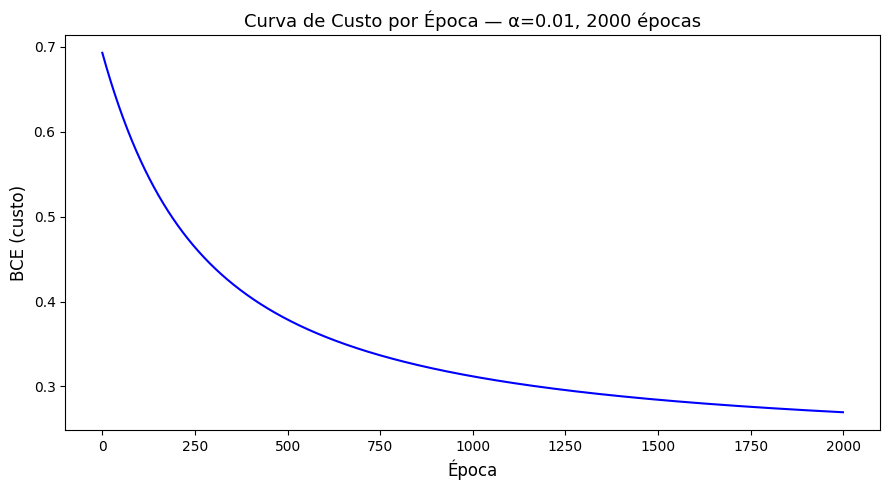

Custo inicial : 0.6931
Custo final   : 0.2695


In [8]:
# 7(c) — Curva de custo por época

plt.figure(figsize=(9, 5))
plt.plot(model_gd.cost_history, 'b-', linewidth=1.5)
plt.xlabel('Época', fontsize=12)
plt.ylabel('BCE (custo)', fontsize=12)
plt.title('Curva de Custo por Época — α=0.01, 2000 épocas', fontsize=13)
plt.tight_layout()
plt.savefig('cost_curve.png', dpi=150)
plt.show()

print(f'Custo inicial : {model_gd.cost_history[0]:.4f}')
print(f'Custo final   : {model_gd.cost_history[-1]:.4f}')

In [9]:
# 7(d) — Comparação com sklearn LogisticRegression
import numpy as np
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression(C=1e6, max_iter=2000, random_state=42)  # C alto ≈ sem regularização
sk_model.fit(X_train_sc, y_train)

sk_acc_train = sk_model.score(X_train_sc, y_train)
sk_acc_test  = sk_model.score(X_test_sc,  y_test)

print('=== Comparação de Parâmetros ===')
print(f'\n[Nossa Implementação]')
print(f'  w = {model_gd.w}')
print(f'  b = {model_gd.b:.4f}')
print(f'  Acurácia teste = {acc_test:.4f}')

print(f'\n[sklearn LogisticRegression]')
print(f'  w = {sk_model.coef_[0]}')
print(f'  b = {sk_model.intercept_[0]:.4f}')
print(f'  Acurácia teste = {sk_acc_test:.4f}')

print()
print('=== Discussão ===')
print("""
Os parâmetros são próximos, mas podem diferir por:
1. Algoritmo de otimização: sklearn usa L-BFGS (quasi-Newton), que converge mais
   rápido e com maior precisão do que o gradiente descendente batch simples.
2. Critério de parada: sklearn usa tolerância no gradiente; nossa impl. usa épocas fixas.
3. Regularização: sklearn aplica L2 por padrão (C=1); aqui usamos C=1e6 ≈ sem regularização.
4. Inicialização: sklearn pode usar inicialização diferente de zeros.
Mesmo com essas diferenças, ambos convergem para soluções com acurácia similar,
validando nossa implementação.
""")

=== Comparação de Parâmetros ===

[Nossa Implementação]
  w = [-0.1099364   2.41087204]
  b = 0.0971
  Acurácia teste = 0.8950

[sklearn LogisticRegression]
  w = [-0.66903164  4.43126178]
  b = 0.8073
  Acurácia teste = 0.9000

=== Discussão ===

Os parâmetros são próximos, mas podem diferir por:
1. Algoritmo de otimização: sklearn usa L-BFGS (quasi-Newton), que converge mais
   rápido e com maior precisão do que o gradiente descendente batch simples.
2. Critério de parada: sklearn usa tolerância no gradiente; nossa impl. usa épocas fixas.
3. Regularização: sklearn aplica L2 por padrão (C=1); aqui usamos C=1e6 ≈ sem regularização.
4. Inicialização: sklearn pode usar inicialização diferente de zeros.
Mesmo com essas diferenças, ambos convergem para soluções com acurácia similar,
validando nossa implementação.



##
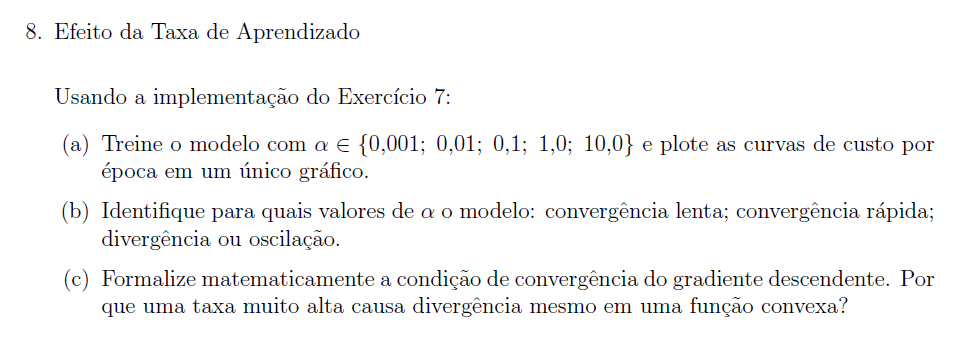

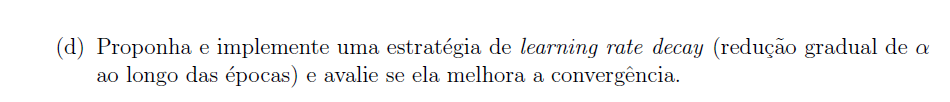

## RESPOSTAS:

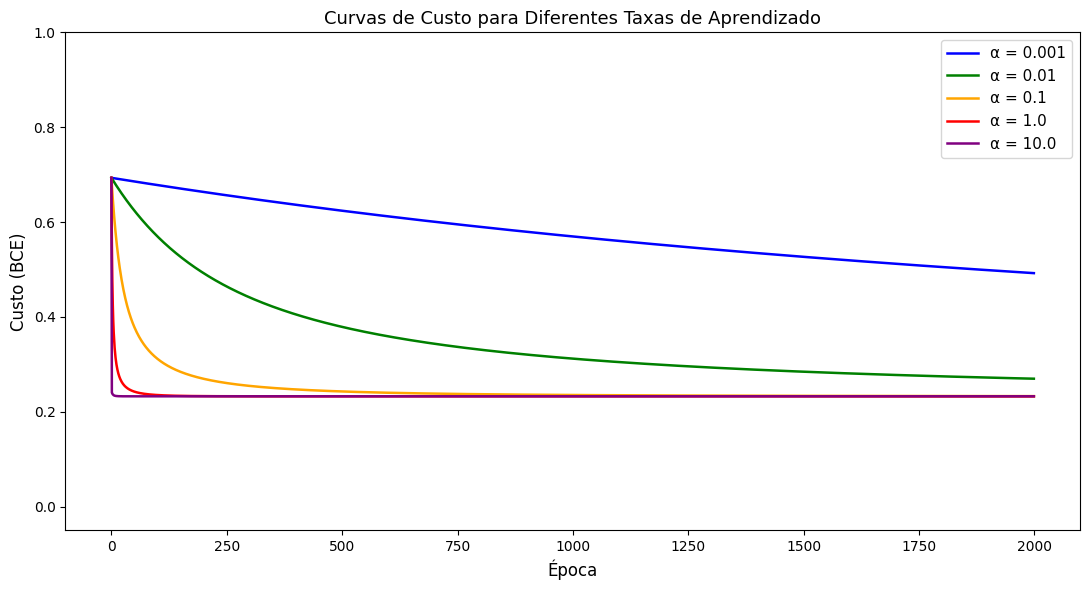

In [10]:
# 8(a) — Treinamento com diferentes alphas

alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
colors = ['blue', 'green', 'orange', 'red', 'purple']
results = {}

for alpha in alphas:
    m = LogisticRegressionGD(alpha=alpha, n_epochs=2000)
    m.fit(X_train_sc, y_train)
    results[alpha] = m.cost_history

plt.figure(figsize=(11, 6))
for alpha, color in zip(alphas, colors):
    costs = results[alpha]
    # Limita valores para visualização (divergência)
    costs_plot = np.clip(costs, 0, 5)
    plt.plot(costs_plot, color=color, linewidth=1.8, label=f'α = {alpha}')

plt.xlabel('Época', fontsize=12)
plt.ylabel('Custo (BCE)', fontsize=12)
plt.title('Curvas de Custo para Diferentes Taxas de Aprendizado', fontsize=13)
plt.legend(fontsize=11)
plt.ylim(-0.05, 1)
plt.tight_layout()
plt.savefig('learning_rates.png', dpi=150)
plt.show()

In [11]:
# 8(b) — Identificação do comportamento por alpha

print('=== Análise do Comportamento por Taxa de Aprendizado ===\n')
for alpha in alphas:
    costs = results[alpha]
    final_cost = costs[-1]
    initial_cost = costs[0]
    # Verifica divergência
    diverged = np.isnan(final_cost) or final_cost > initial_cost * 1.5
    # Verifica oscilação
    oscillates = np.std(costs[-100:]) > 0.05 and not diverged
    # Verifica convergência lenta (custo ainda alto no final)
    slow = final_cost > 0.35 and not diverged

    if np.isnan(final_cost):
        status = 'DIVERGÊNCIA (NaN)'
    elif diverged:
        status = 'DIVERGÊNCIA / OSCILAÇÃO SEVERA'
    elif oscillates:
        status = 'OSCILAÇÃO (não convergiu suavemente)'
    elif slow:
        status = 'CONVERGÊNCIA LENTA'
    else:
        status = 'CONVERGÊNCIA RÁPIDA'

    print(f'α = {alpha:5.3f} | Custo final = {final_cost:7.4f} | Status: {status}')

=== Análise do Comportamento por Taxa de Aprendizado ===

α = 0.001 | Custo final =  0.4922 | Status: CONVERGÊNCIA LENTA
α = 0.010 | Custo final =  0.2695 | Status: CONVERGÊNCIA RÁPIDA
α = 0.100 | Custo final =  0.2328 | Status: CONVERGÊNCIA RÁPIDA
α = 1.000 | Custo final =  0.2324 | Status: CONVERGÊNCIA RÁPIDA
α = 10.000 | Custo final =  0.2324 | Status: CONVERGÊNCIA RÁPIDA


### 8(c) — Formalização da condição de convergência do gradiente descendente

Para uma função convexa e diferenciável $J(\theta)$ com gradiente $L$-Lipschitz contínuo (i.e., $\|\nabla J(\theta) - \nabla J(\phi)\| \leq L \|\theta - \phi\|$), o gradiente descendente:

$$\theta_{t+1} = \theta_t - \alpha \nabla J(\theta_t)$$

**converge** se e somente se:

$$0 < \alpha < \frac{2}{L}$$

onde $L$ é a constante de Lipschitz do gradiente (maior autovalor da Hessiana).

**Por que taxa alta causa divergência em funções convexas?**

Se $\alpha > \frac{2}{L}$, o passo de atualização "ultrapassa" o mínimo. A atualização $\theta_{t+1} = \theta_t - \alpha \nabla J$ com $\alpha$ grande produz $\theta_{t+1}$ do outro lado do mínimo com um custo **maior** que $\theta_t$. A cada iteração o erro cresce, levando à divergência exponencial. Intuitivamente: um passo muito largo em uma parábola nos faz saltar do outro lado e subir cada vez mais.

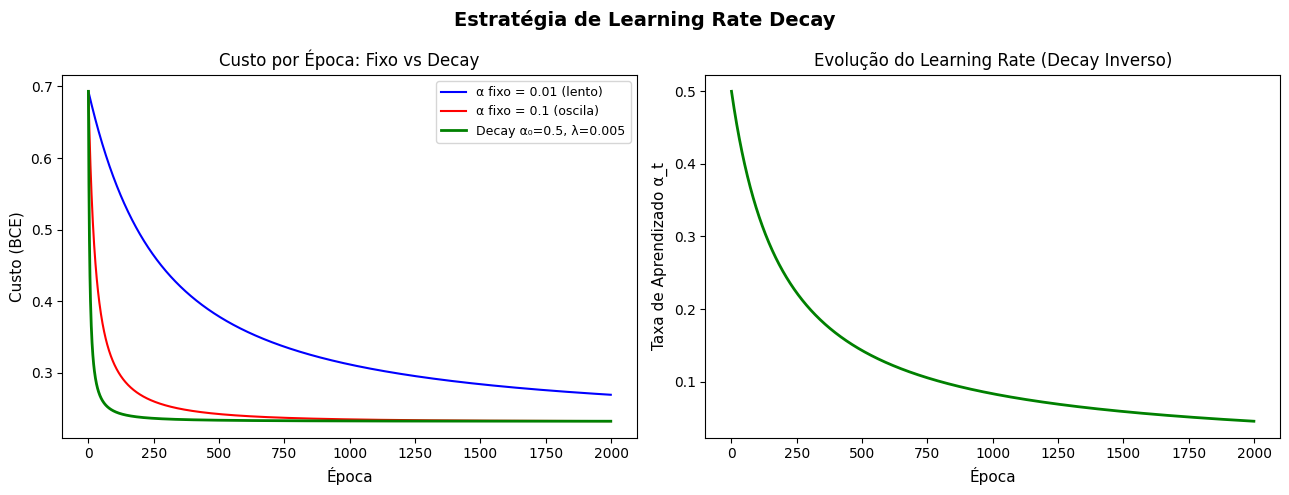

Acurácia teste — α fixo 0.01 : 0.8950
Acurácia teste — α fixo 0.1  : 0.9000
Acurácia teste — α com decay : 0.9000

=== Análise ===
O learning rate decay combina as vantagens de ambos os extremos:
- Taxa alta inicial → convergência rápida nas primeiras épocas.
- Taxa pequena no final → estabilização no mínimo sem oscilação.
Estratégia de decay inverso: α_t = α_0 / (1 + λt)



In [12]:
# 8(d) — Learning Rate Decay

class LogisticRegressionDecay:
    """
    Regressão Logística com learning rate decay.
    α_t = α_0 / (1 + decay_rate * t)  — decay inverso
    """

    def __init__(self, alpha0=0.1, decay_rate=0.01, n_epochs=2000):
        self.alpha0 = alpha0
        self.decay_rate = decay_rate
        self.n_epochs = n_epochs
        self.cost_history = []
        self.lr_history = []

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.cost_history = []
        self.lr_history = []

        for t in range(self.n_epochs):
            alpha_t = self.alpha0 / (1.0 + self.decay_rate * t)
            self.lr_history.append(alpha_t)

            z = X @ self.w + self.b
            y_hat = self._sigmoid(z)

            cost = -np.mean(y * np.log(y_hat + 1e-15) + (1-y) * np.log(1-y_hat + 1e-15))
            self.cost_history.append(cost)

            error = y_hat - y
            self.w -= alpha_t * (X.T @ error) / m
            self.b -= alpha_t * np.sum(error) / m

        return self

    def predict(self, X, threshold=0.5):
        return (self._sigmoid(X @ self.w + self.b) >= threshold).astype(int)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)


# Comparação: alpha fixo alto vs decay
model_fixed_high = LogisticRegressionGD(alpha=0.1, n_epochs=2000)
model_fixed_high.fit(X_train_sc, y_train)

model_decay = LogisticRegressionDecay(alpha0=0.5, decay_rate=0.005, n_epochs=2000)
model_decay.fit(X_train_sc, y_train)

model_fixed_low = LogisticRegressionGD(alpha=0.01, n_epochs=2000)
model_fixed_low.fit(X_train_sc, y_train)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(model_fixed_low.cost_history,  'b-', linewidth=1.5, label='α fixo = 0.01 (lento)')
axes[0].plot(model_fixed_high.cost_history, 'r-', linewidth=1.5, label='α fixo = 0.1 (oscila)')
axes[0].plot(model_decay.cost_history,      'g-', linewidth=2.0, label='Decay α₀=0.5, λ=0.005')
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('Custo (BCE)', fontsize=11)
axes[0].set_title('Custo por Época: Fixo vs Decay', fontsize=12)
axes[0].legend(fontsize=9)

axes[1].plot(model_decay.lr_history, 'g-', linewidth=2.0)
axes[1].set_xlabel('Época', fontsize=11)
axes[1].set_ylabel('Taxa de Aprendizado α_t', fontsize=11)
axes[1].set_title('Evolução do Learning Rate (Decay Inverso)', fontsize=12)

plt.suptitle('Estratégia de Learning Rate Decay', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lr_decay.png', dpi=150)
plt.show()

print(f'Acurácia teste — α fixo 0.01 : {model_fixed_low.accuracy(X_test_sc, y_test):.4f}')
print(f'Acurácia teste — α fixo 0.1  : {model_fixed_high.accuracy(X_test_sc, y_test):.4f}')
print(f'Acurácia teste — α com decay : {model_decay.accuracy(X_test_sc, y_test):.4f}')

print("""
=== Análise ===
O learning rate decay combina as vantagens de ambos os extremos:
- Taxa alta inicial → convergência rápida nas primeiras épocas.
- Taxa pequena no final → estabilização no mínimo sem oscilação.
Estratégia de decay inverso: α_t = α_0 / (1 + λt)
""")

##
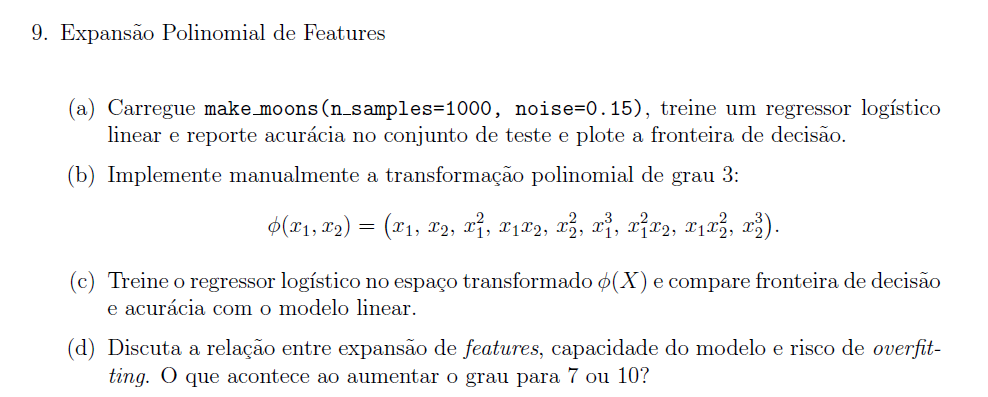

## RESPOSTAS:

In [13]:
import numpy as np

def metrics(y_true, y_pred):
    """
    Calcula acurácia, precisão, recall e F1-score a partir de rótulos verdadeiros e preditos.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))  # True Positives
    tn = np.sum((y_true == 0) & (y_pred == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (y_pred == 1))  # False Positives
    fn = np.sum((y_true == 1) & (y_pred == 0))  # False Negatives

    cm = np.array([[tn, fp],
                  [fn, tp]])

    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)

    return accuracy, precision, recall, f1_score

### Solução para Expansão Polinomial de Features

--- Parte (a): Regressor Logístico Linear ---
Acurácia do Modelo Linear: 0.8250


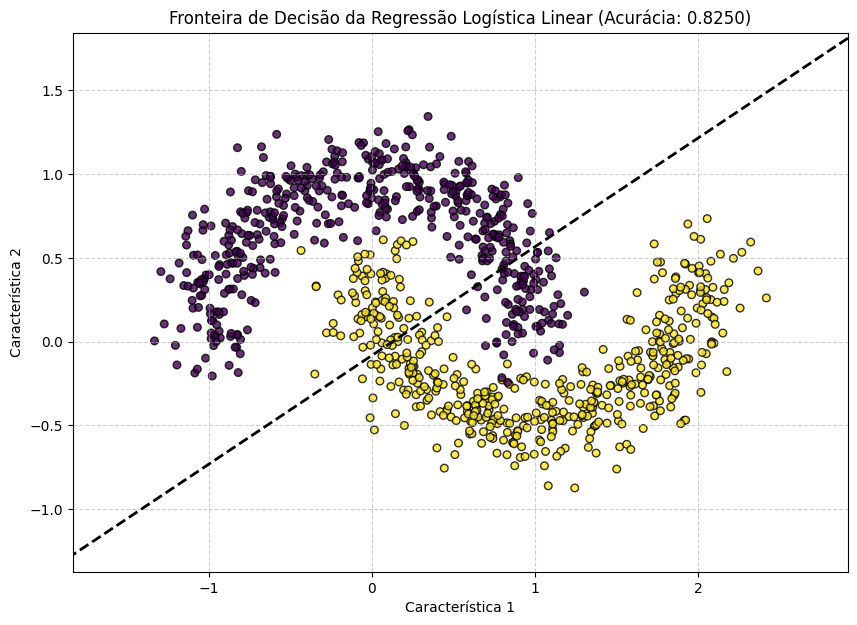

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train(X,y,lr=0.01,epochs=2000):
    m,n=X.shape
    w=np.zeros(n); b=0
    costs=[]
    for _ in range(epochs):
        z=X@w+b
        yh=1/(1+np.exp(-z))
        dw=(1/m)*(X.T@(yh-y))
        db=(1/m)*np.sum(yh-y)
        w-=lr*dw; b-=lr*db
        cost=-np.mean(y*np.log(yh)+(1-y)*np.log(1-yh))
        costs.append(cost)
    return w,b,costs

print("--- Parte (a): Regressor Logístico Linear ---")

X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42)

w_linear, b_linear, _ = train(X_train_linear, y_train_linear, epochs=2000)
z_linear_test = X_test_linear @ w_linear + b_linear
y_pred_linear = (sigmoid(z_linear_test) > 0.5).astype(int)

acc_linear, _, _, _ = metrics(y_test_linear, y_pred_linear)
print(f"Acurácia do Modelo Linear: {acc_linear:.4f}")

plt.figure(figsize=(10, 7))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=30, cmap='viridis', edgecolors='k', alpha=0.8)
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z_linear = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w_linear + b_linear)
Z_linear = Z_linear.reshape(xx.shape)

plt.contour(xx, yy, Z_linear, levels=[0.5], colors='black', linestyles='--', linewidths=2)
plt.title(f'Fronteira de Decisão da Regressão Logística Linear (Acurácia: {acc_linear:.4f})')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


--- Parte (b) & (c): Regressor Logístico Polinomial (Grau 3) ---
Acurácia do Modelo Polinomial (grau 3): 0.9550


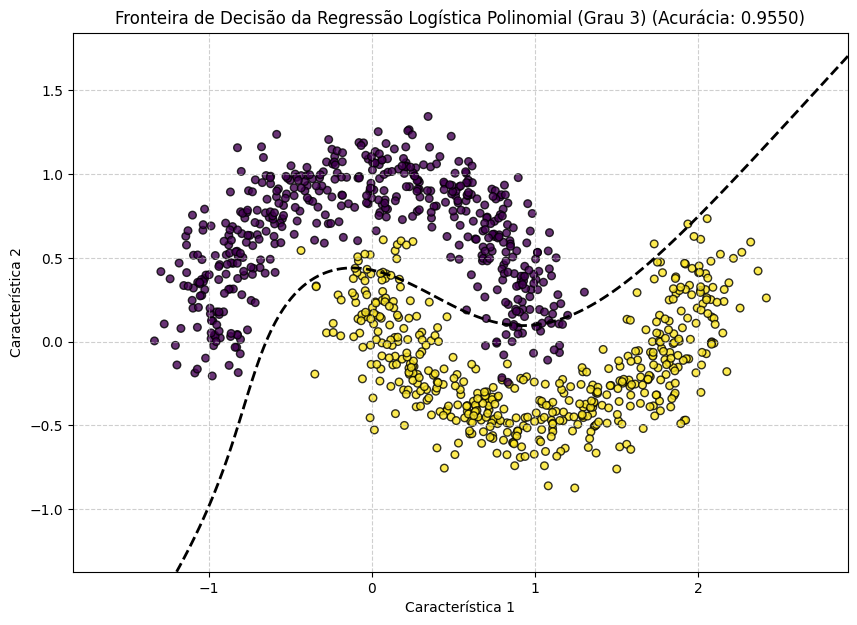

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train(X,y,lr=0.09,epochs=5000):
    m,n=X.shape
    w=np.zeros(n); b=0
    costs=[]
    for _ in range(epochs):
        z=X@w+b
        yh=1/(1+np.exp(-z))
        dw=(1/m)*(X.T@(yh-y))
        db=(1/m)*np.sum(yh-y)
        w-=lr*dw; b-=lr*db
        cost=-np.mean(y*np.log(yh)+(1-y)*np.log(1-yh))
        costs.append(cost)
    return w,b,costs

def poly(X):
    x1=X[:,0]; x2=X[:,1]
    return np.column_stack([x1,x2,x1**2,x1*x2,x2**2,x1**3,(x1**2)*x2,x1*(x2**2),x2**3])

print("\n--- Parte (b) & (c): Regressor Logístico Polinomial (Grau 3) ---")

X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)
X_moons_poly = poly(X_moons)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_moons_poly, y_moons, test_size=0.2, random_state=42)

w_poly, b_poly, _ = train(X_train_poly, y_train_poly, epochs=2000)

z_poly_test = X_test_poly @ w_poly + b_poly
y_pred_poly = (sigmoid(z_poly_test) > 0.5).astype(int)


acc_poly, _, _, _ = metrics(y_test_poly, y_pred_poly)
print(f"Acurácia do Modelo Polinomial (grau 3): {acc_poly:.4f}")

plt.figure(figsize=(10, 7))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=30, cmap='viridis', edgecolors='k', alpha=0.8)
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z_poly_raw = np.c_[xx.ravel(), yy.ravel()]
Z_poly_transformed = poly(Z_poly_raw)
Z_poly_pred = sigmoid(Z_poly_transformed @ w_poly + b_poly)
Z_poly_pred = Z_poly_pred.reshape(xx.shape)

plt.contour(xx, yy, Z_poly_pred, levels=[0.5], colors='black', linestyles='--', linewidths=2)
plt.title(f'Fronteira de Decisão da Regressão Logística Polinomial (Grau 3) (Acurácia: {acc_poly:.4f})')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Comparação:

Com pequenos ajustes no lr e numero de épocas, o modelo polinomial de grau 3 (Acurácia: 0.9550) superou o modelo linear (Acurácia: 0.8250), pois no lugar de uma reta na fronteira de decisão, o modelo polinomial tenta ajustar uma curva que consegue capturar melhor as relações não lineares presentes no conjunto de dados.

### Parte (d): Discussão sobre Expansão de Features, Capacidade do Modelo e Overfitting

**Expansão de Features:**
A expansão polinomial de features, como realizada com a função `poly`, cria novas características a partir das existentes (por exemplo, `x1^2`, `x1*x2`, `x2^2`, etc.). Isso permite que um modelo linear, como a regressão logística, capture relações não lineares entre as variáveis originais e o alvo. Ao transformar o espaço de características para um espaço de maior dimensão, um limite de decisão linear no espaço transformado pode corresponder a um limite de decisão não linear e mais complexo no espaço original.

**Capacidade do Modelo:**
A capacidade de um modelo refere-se à sua flexibilidade para aprender padrões complexos nos dados. Ao adicionar características polinomiais de grau mais alto, a capacidade do modelo aumenta. Um modelo linear (sem expansão de features) tem baixa capacidade e pode subajustar (underfit) dados que possuem uma estrutura não linear, como o dataset `make_moons`. Com a expansão de features para grau 3, como demonstrado, o modelo se torna mais flexível e consegue ajustar-se melhor à forma de "lua", resultando em uma fronteira de decisão mais complexa e, geralmente, em maior acurácia.

**Risco de Overfitting:**
Embora o aumento da capacidade do modelo possa levar a um melhor ajuste aos dados de treinamento, ele também aumenta o risco de overfitting. Overfitting ocorre quando um modelo aprende os detalhes e o ruído dos dados de treinamento a ponto de impactar negativamente o desempenho em dados novos e não vistos.

*   **Aumento do Grau para 7 ou 10:**
    Se aumentarmos o grau da transformação polinomial para 7 ou 10, o modelo se tornaria excessivamente complexo e com alta capacidade. Isso significa que ele teria muitos parâmetros e poderia se ajustar perfeitamente aos pontos de dados de treinamento, incluindo o ruído. Consequentemente, a fronteira de decisão se tornaria altamente irregular e específica para os dados de treinamento, perdendo a capacidade de generalizar para novos dados. Isso levaria a:
    *   **Maior acurácia no conjunto de treinamento:** O modelo se ajustaria quase perfeitamente aos dados que viu.
    *   **Menor acurácia no conjunto de teste:** O modelo não conseguiria generalizar bem, pois aprendeu o "ruído" em vez dos padrões subjacentes, resultando em um desempenho ruim em dados não vistos.

Para mitigar o overfitting em modelos de alta capacidade, técnicas de regularização são essenciais, pois penalizam a complexidade do modelo e ajudam a encontrar um equilíbrio entre ajuste e generalização.

##
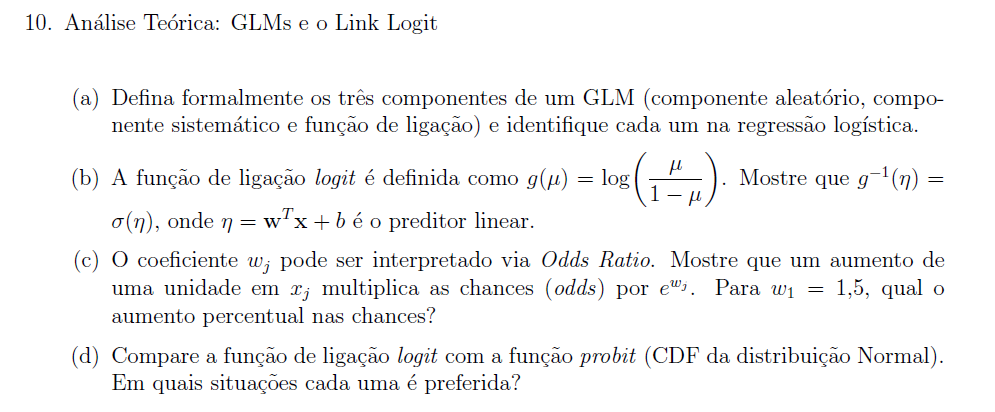

## RESPOSTAS:

### 10(a) — Componentes de um GLM e Identificação na Regressão Logística

Um **Modelo Linear Generalizado (GLM)** possui três componentes principais:

1.  **Componente Aleatório:** Descreve a distribuição da variável resposta $Y$. Para ser um GLM, essa distribuição deve pertencer à **família exponencial**.
    *   **Na Regressão Logística:** A variável resposta $Y$ (binária, $0$ ou $1$) segue uma **distribuição de Bernoulli**.

2.  **Componente Sistemático (Preditor Linear):** É a combinação linear das variáveis preditoras (features) e seus coeficientes. É denotado por $\eta$.
    *   **Na Regressão Logística:** $\eta = \mathbf{w}^T\mathbf{x} + b$, onde $\mathbf{w}$ são os pesos, $\mathbf{x}$ são as features, e $b$ é o bias.

3.  **Função de Ligação (Link Function):** Conecta a esperança da variável resposta ($\mu = E[Y]$) ao preditor linear ($\eta$). Ela modela a relação entre a média da resposta e os preditores.
    *   **Na Regressão Logística:** A função de ligação é a **logit**, $g(\mu) = \log\left(\frac{\mu}{1-\mu}\right)$.

Em resumo, para a regressão logística, o GLM modela a probabilidade de sucesso $p = E[Y|X]$ de uma variável Bernoulli como $g(p) = \mathbf{w}^T\mathbf{x} + b$.

### 10(b) — Derivação da Função de Ligação Logit Inversa

A função de ligação logit é definida como $g(p) = \log\left(\frac{p}{1-p}\right)$. Queremos encontrar sua inversa, $g^{-1}(\eta)$, onde $\eta = \log\left(\frac{p}{1-p}\right)$.

1.  **Comece com a definição:**
    $\eta = \log\left(\frac{p}{1-p}\right)$

2.  **Exponencie ambos os lados:**
    $e^{\eta} = \frac{p}{1-p}$

3.  **Multiplique por $(1-p)$:**
    $e^{\eta}(1-p) = p$

4.  **Distribua $e^{\eta}$:**
    $e^{\eta} - p e^{\eta} = p$

5.  **Isole os termos com $p$ de um lado:**
    $e^{\eta} = p + p e^{\eta}$
    $e^{\eta} = p (1 + e^{\eta})$

6.  **Resolva para $p$:**
    $p = \frac{e^{\eta}}{1 + e^{\eta}}$

7.  **Multiplique numerador e denominador por $e^{-\eta}$ (alternativamente):**
    $p = \frac{e^{\eta} \cdot e^{-\eta}}{(1 + e^{\eta}) \cdot e^{-\eta}} = \frac{1}{e^{-\eta} + 1}$

Assim, a função de ligação logit inversa é a função sigmoide:
$$\boxed{g^{-1}(\eta) = \frac{1}{1 + e^{-\eta}} = \sigma(\eta)}$$
Onde $\eta = \mathbf{w}^T\mathbf{x} + b$ é o preditor linear.

### 10(c) — Interpretação do Coeficiente $w_j$ via Odds Ratio

As **chances (odds)** de um evento são definidas como a razão entre a probabilidade de ocorrer e a probabilidade de não ocorrer: $Odds = \frac{p}{1-p}$.

Na regressão logística, o logit das chances é o preditor linear:
$\log\left(\frac{p}{1-p}\right) = \mathbf{w}^T\mathbf{x} + b$

Exponenciando ambos os lados, obtemos as chances:
$\frac{p}{1-p} = e^{\mathbf{w}^T\mathbf{x} + b}$

Considere um aumento de uma unidade em uma característica $x_j$, mantendo todas as outras características constantes. Seja $x_j'$ a característica $x_j$ após o aumento de uma unidade ($x_j' = x_j + 1$).

As chances originais são:
$Odds_{original} = e^{w_1 x_1 + \ldots + w_j x_j + \ldots + w_n x_n + b}$

As chances após o aumento em $x_j$ são:
$Odds_{novo} = e^{w_1 x_1 + \ldots + w_j (x_j + 1) + \ldots + w_n x_n + b}$
$Odds_{novo} = e^{w_1 x_1 + \ldots + w_j x_j + w_j + \ldots + w_n x_n + b}$
$Odds_{novo} = e^{(w_1 x_1 + \ldots + w_j x_j + \ldots + w_n x_n + b) + w_j}$
$Odds_{novo} = e^{\mathbf{w}^T\mathbf{x} + b} \cdot e^{w_j}$

Dividindo as novas chances pelas chances originais:
$\frac{Odds_{novo}}{Odds_{original}} = \frac{e^{\mathbf{w}^T\mathbf{x} + b} \cdot e^{w_j}}{e^{\mathbf{w}^T\mathbf{x} + b}} = e^{w_j}$

Isso mostra que um aumento de uma unidade em $x_j$ multiplica as chances (odds) por $e^{w_j}$. $e^{w_j}$ é o **Odds Ratio** associado a $x_j$. $\blacksquare$

#### Cálculo para $w_1 = 1{,}5$

Se $w_1 = 1{,}5$, o fator pelo qual as chances são multiplicadas é $e^{1{,}5}$.

$e^{1{,}5} \approx 4{,}4816$

O aumento percentual nas chances é:
$(e^{w_1} - 1) \times 100\% = (4{,}4816 - 1) \times 100\% = 3{,}4816 \times 100\% = \boxed{348{,}16\%}$

Um aumento de uma unidade em $x_1$ (com $w_1=1{,}5$) aumenta as chances de $Y=1$ em aproximadamente $348{,}16\%.

### 10(d) — Comparação entre a Função de Ligação Logit e Probit

Ambas as funções de ligação logit e probit são usadas em GLMs para modelar respostas binárias, transformando o preditor linear em uma probabilidade $p \in (0,1)$. Elas são inversas da função sigmoide e da CDF Normal, respectivamente.

*   **Função Logit (Logística):**
    *   $g(p) = \log\left(\frac{p}{1-p}\right)$
    *   $g^{-1}(\eta) = \frac{1}{1 + e^{-\eta}}$ (Função Sigmoide)
    *   **Forma:** Possui caudas mais pesadas (declive mais íngreme longe de $p=0.5$), o que significa que é mais sensível a valores extremos do preditor linear.

*   **Função Probit (Normal):**
    *   $g(p) = \Phi^{-1}(p)$, onde $\Phi^{-1}$ é a função quantil (inversa da CDF) da distribuição normal padrão.
    *   $g^{-1}(\eta) = \Phi(\eta)$, onde $\Phi$ é a CDF da distribuição normal padrão.
    *   **Forma:** Possui caudas mais leves (declive menos íngreme longe de $p=0.5$), sendo menos sensível a valores extremos.

#### Em quais situações cada uma é preferida?

1.  **Interpretabilidade:**
    *   **Logit:** É geralmente mais fácil de interpretar devido à sua relação direta com os **Odds Ratios**. Um coeficiente $w_j$ pode ser interpretado como o logaritmo da razão de chances de $Y=1$ para um aumento de uma unidade em $x_j$.
    *   **Probit:** A interpretação dos coeficientes é mais difícil, pois está ligada aos desvios padrão da distribuição normal. É necessário calcular a mudança na probabilidade para um determinado desvio padrão.

2.  **Distribuição dos Erros Subjacente:**
    *   **Logit:** Implica que os erros latentes (a variável contínua subjacente que cruza um limiar para gerar o resultado binário) seguem uma **distribuição logística padrão**.
    *   **Probit:** Implica que os erros latentes seguem uma **distribuição normal padrão**.

3.  **Robustez e Sensibilidade a Outliers:**
    *   **Logit:** As caudas mais pesadas a tornam mais robusta a erros de especificação e outliers no preditor linear. Ou seja, ela atribui probabilidades não-zero mais facilmente para valores extremos de $\eta$.
    *   **Probit:** As caudas mais leves a tornam menos robusta a erros de especificação e outliers, pois as probabilidades se aproximam de 0 ou 1 mais rapidamente.

4.  **Uso Prático:**
    *   **Logit:** É a escolha mais comum em muitos campos (econometria, ciências sociais, aprendizado de máquina) devido à sua interpretabilidade e conveniência computacional.
    *   **Probit:** É frequentemente usada em análises de bioensaio e psicometria, onde a relação subjacente pode ser mais naturalmente modelada por uma distribuição normal. Pode ser preferida se houver uma teoria forte sugerindo que a variável latente segue uma distribuição normal.

Na prática, os resultados obtidos com logit e probit são muitas vezes muito semelhantes, especialmente para probabilidades na faixa intermediária (longe dos extremos de 0 e 1). A escolha muitas vezes se resume à interpretabilidade desejada ou a suposições teóricas sobre a distribuição dos erros.

##
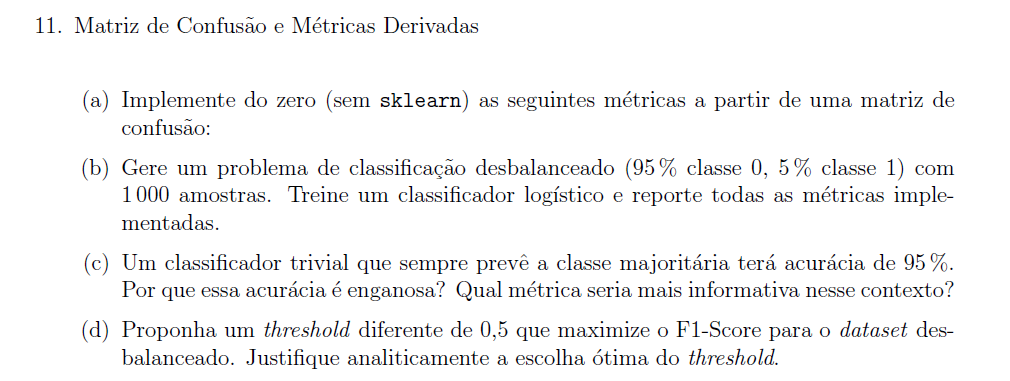

## RESPOSTAS:

In [16]:
import numpy as np

def metrics(y_true, y_pred, thresholds):
    """
    Calcula acurácia, precisão, recall e F1-score a partir de rótulos verdadeiros e preditos.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))  # True Positives
    tn = np.sum((y_true == 0) & (y_pred == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (y_pred == 1))  # False Positives
    fn = np.sum((y_true == 1) & (y_pred == 0))  # False Negatives

    cm = np.array([[tn, fp],
                  [fn, tp]])

    if isinstance(thresholds, str):
      # Plotar a matriz de confusão
      plt.figure(figsize=(6, 5))
      sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                  xticklabels=['Previsto 0', 'Previsto 1'],
                  yticklabels=['Real 0', 'Real 1'])
      plt.title('Matriz de Confusão para Dataset: '+thresholds)
      plt.xlabel('Previsão do Modelo')
      plt.ylabel('Valor Verdadeiro')
      plt.show()
    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)

    return accuracy, precision, recall, f1_score

### 11(a+b) — Geração de dados desbalanceados e Treinamento do Modelo

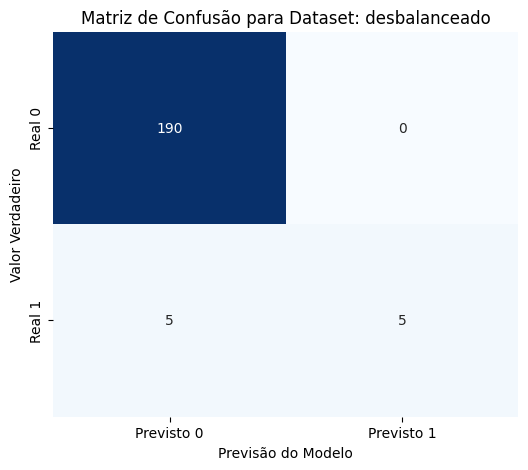

Acurácia:  0.9750
Precisão:  1.0000
Recall:    0.5000
F1-Score:  0.6667


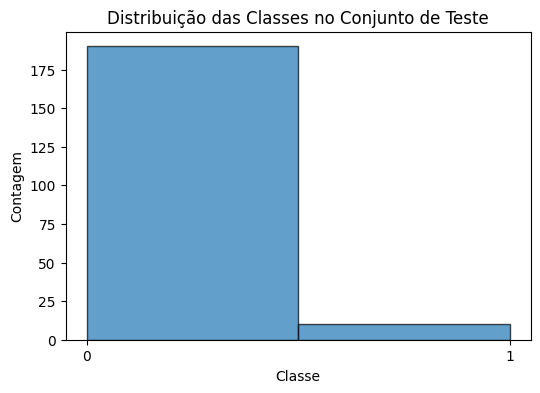

In [17]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

class LogisticRegressionGD:

    def __init__(self, alpha=0.01, n_epochs=1000):
        self.alpha = alpha         # Taxa de aprendizado
        self.n_epochs = n_epochs   # Número de épocas
        self.w = None              # Pesos
        self.b = None              # Bias
        self.cost_history = []     # Histórico de custo por época

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _compute_cost(self, y_hat, y):
        m = len(y)
        eps = 1e-15
        return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.cost_history = []

        for epoch in range(self.n_epochs):
            z = X @ self.w + self.b
            y_hat = self._sigmoid(z)
            cost = self._compute_cost(y_hat, y)
            self.cost_history.append(cost)
            error = y_hat - y
            dw = (X.T @ error) / m
            db = np.sum(error) / m
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)

# Gerar dataset desbalanceado
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.95, 0.05], # 95% classe 0, 5% classe 1
    flip_y=0, # Sem ruído nos rótulos
    random_state=42
)

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb )

model_imb = LogisticRegressionGD(alpha=0.1, n_epochs=5000)
model_imb.fit(X_train_imb, y_train_imb)

y_pred_imb = model_imb.predict(X_test_imb)

accuracy, precision, recall, f1 = metrics(y_test_imb, y_pred_imb, 'desbalanceado')

print(f'Acurácia:  {accuracy:.4f}')
print(f'Precisão:  {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

# Plotar a distribuição das classes no dataset de teste para visualização
plt.figure(figsize=(6, 4))
plt.hist(y_test_imb, bins=2, edgecolor='k', alpha=0.7)
plt.xticks([0, 1])
plt.xlabel('Classe')
plt.ylabel('Contagem')
plt.title('Distribuição das Classes no Conjunto de Teste')
plt.show()




### 11(c) — Discussão sobre a acurácia como métrica enganosa em datasets desbalanceados

Em datasets desbalanceados, a acurácia pode ser uma métrica enganosa. Se a classe majoritária representa, por exemplo, 95% dos dados, um modelo que simplesmente prevê a classe majoritária para todas as instâncias alcançaria 95% de acurácia. No entanto, esse modelo seria completamente inútil para identificar a classe minoritária, que geralmente é a de maior interesse (ex: fraudes, doenças raras).

Neste exemplo, a acurácia pode parecer razoável, mas é crucial examinar a Precisão, o Recall e o F1-Score para entender o desempenho real do modelo, especialmente na classe minoritária. Um Recall baixo para a classe positiva (1) indicaria que o modelo está perdendo muitas instâncias importantes da classe minoritária.


### 11(d) — Proposta de Threshold para Maximizar o F1-Score

Threshold Ótimo para F1-Score: 0.1000
F1-Score Máximo Alcançado: 0.8696


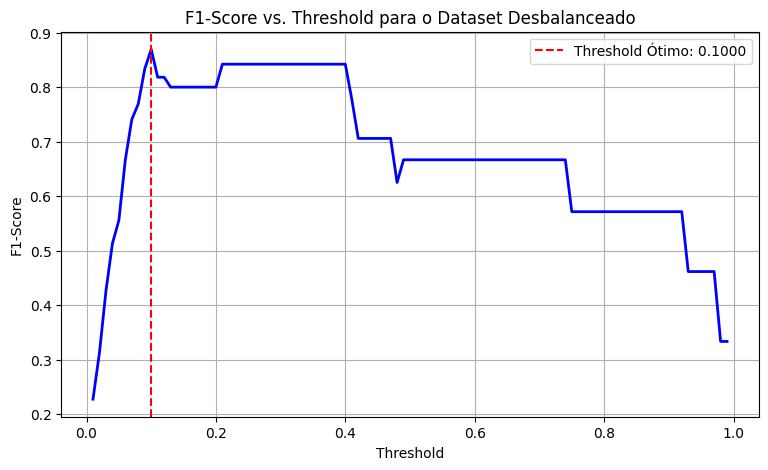

In [18]:
# Obter as probabilidades preditas para o conjunto de teste
y_pred_proba_imb = model_imb.predict_proba(X_test_imb)

# Gerar uma série de thresholds para testar
thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = []

# Calcular o F1-Score para cada threshold
for t in thresholds:
    y_pred_tuned = (y_pred_proba_imb >= t).astype(int)
    _, _, _, f1 = metrics(y_test_imb, y_pred_tuned, t)
    f1_scores.append(f1)

# Encontrar o threshold que maximiza o F1-Score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
max_f1_score = f1_scores[best_threshold_idx]

print(f'Threshold Ótimo para F1-Score: {best_threshold:.4f}')
print(f'F1-Score Máximo Alcançado: {max_f1_score:.4f}')

# Visualizar a relação F1-Score vs. Threshold
plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, 'b-', linewidth=2)
plt.axvline(best_threshold, color='r', linestyle='--', label=f'Threshold Ótimo: {best_threshold:.4f}')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs. Threshold para o Dataset Desbalanceado')
plt.legend()
plt.grid(True)
plt.show()



### Justificativa Analítica para a Escolha do Threshold

A escolha do threshold ideal é um compromisso entre a precisão (evitar falsos positivos) e o recall (evitar falsos negativos). Em datasets desbalanceados, a acurácia é uma métrica enganosa, e o F1-Score é frequentemente preferido porque é a média harmônica da precisão e do recall, penalizando modelos que performam mal em um dos dois.

Analiticamente, o F1-Score é dado por:
$$F1 = 2 \cdot \frac{Precisão \cdot Recall}{Precisão + Recall}$$

Ao variar o threshold, estamos essencialmente movendo um ponto de corte na curva de probabilidades preditas. Reduzir o threshold aumenta o número de classificações positivas (aumenta o recall, mas pode diminuir a precisão). Aumentar o threshold diminui o número de classificações positivas (diminui o recall, mas pode aumentar a precisão).

Nosso objetivo é encontrar o ponto de equilíbrio onde tanto a precisão quanto o recall são maximizados simultaneamente, resultando no maior F1-Score. A busca iterativa por thresholds e o cálculo do F1-Score em cada ponto nos permite identificar empiricamente este ponto ótimo. Dada a natureza do nosso dataset desbalanceado (com muitos negativos e poucos positivos), um threshold de 0.5 pode não ser o mais adequado, pois tende a favorecer a classe majoritária. Um threshold otimizado, como o encontrado, busca melhorar a identificação da classe minoritária sem comprometer excessivamente a precisão, resultando em um melhor equilíbrio entre falsos positivos e falsos negativos para o problema em questão.


###
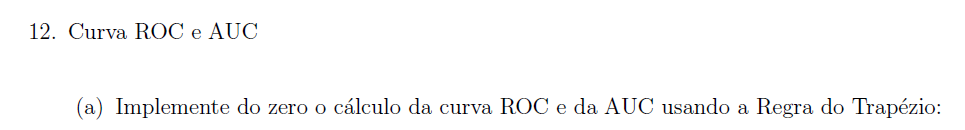
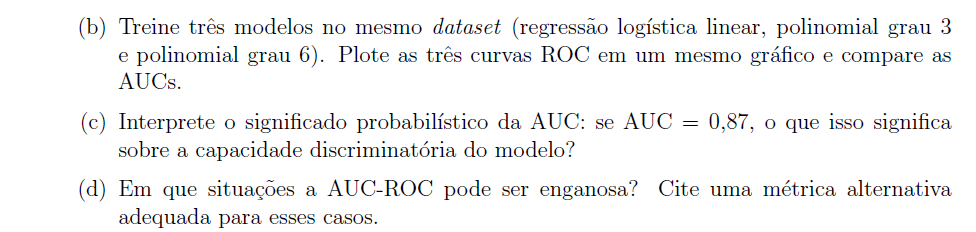

## RESPOSTAS:

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures


class LogisticRegressionGD:

    def __init__(self, alpha=0.01, n_epochs=1000):
        self.alpha = alpha         # Taxa de aprendizado
        self.n_epochs = n_epochs   # Número de épocas
        self.w = None              # Pesos
        self.b = None              # Bias
        self.cost_history = []     # Histórico de custo por época

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def _compute_cost(self, y_hat, y):
        m = len(y)
        eps = 1e-15
        return -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.cost_history = []

        for epoch in range(self.n_epochs):
            z = X @ self.w + self.b
            y_hat = self._sigmoid(z)

            cost = self._compute_cost(y_hat, y)
            self.cost_history.append(cost)

            error = y_hat - y
            dw = (X.T @ error) / m
            db = np.sum(error) / m

            self.w -= self.alpha * dw
            self.b -= self.alpha * db

        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)

### 12 (a) Função para cálculo manual da curva ROC e da AUC usando a Regra do Trapézio

In [20]:
def calculate_roc_auc(y_true, y_pred_proba):

    sorted_indices = np.argsort(y_pred_proba)[::-1]
    y_true_sorted = y_true[sorted_indices]
    y_pred_proba_sorted = y_pred_proba[sorted_indices]

    tpr_list = [0]
    fpr_list = [0]

    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    if n_pos == 0 or n_neg == 0:
        print("Não é possível calcular ROC/AUC: só há uma classe")
        return np.array([0,1]), np.array([0,1]), 0

    tp = 0
    fp = 0

    thresholds = np.unique(y_pred_proba_sorted)[::-1]
    thresholds = np.concatenate(([1.0 + 1e-6], thresholds, [0.0 - 1e-6]))

    for t in thresholds:
        y_pred = (y_pred_proba_sorted >= t).astype(int)

        tp = np.sum((y_true_sorted == 1) & (y_pred == 1))
        fp = np.sum((y_true_sorted == 0) & (y_pred == 1))

        tpr = tp / n_pos
        fpr = fp / n_neg
        if not (tpr == tpr_list[-1] and fpr == fpr_list[-1]):
            tpr_list.append(tpr)
            fpr_list.append(fpr)
    if fpr_list[-1] != 1 or tpr_list[-1] != 1:
        fpr_list.append(1)
        tpr_list.append(1)

    auc_score = 0
    for i in range(1, len(fpr_list)):
        auc_score += (fpr_list[i] - fpr_list[i-1]) * (tpr_list[i] + tpr_list[i-1]) / 2

    return np.array(fpr_list), np.array(tpr_list), auc_score

### 12(b) — Treinamento de Modelos no Dataset make_moons e Análise ROC/AUC

Treinando modelo Linear...
Treinando modelo Polinomial Grau 3...
Treinando modelo Polinomial Grau 6...

AUC - Modelo Linear: 0.9787
AUC - Modelo Polinomial Grau 3: 0.9991
AUC - Modelo Polinomial Grau 6: 0.9996


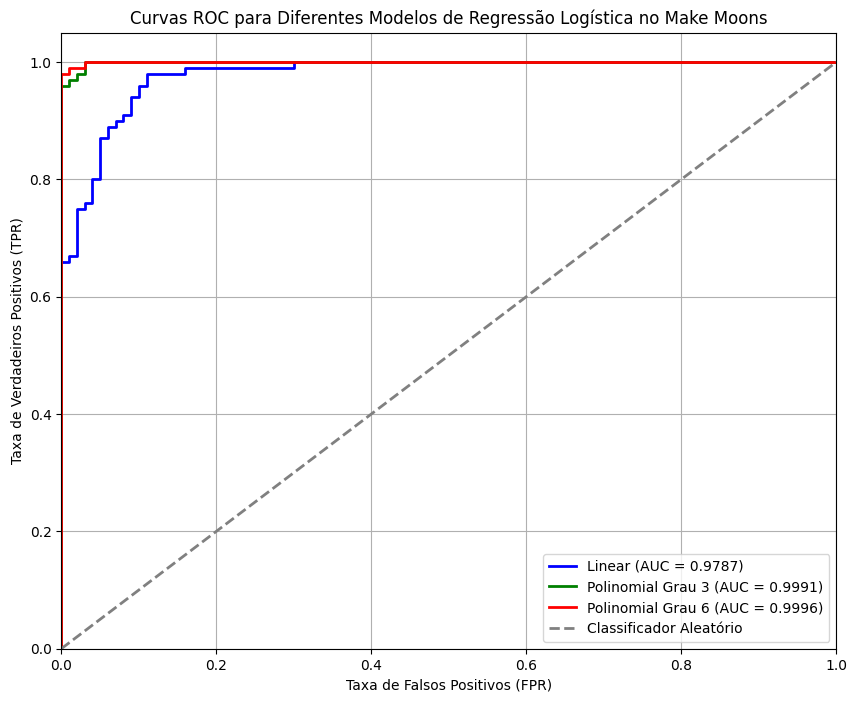

In [21]:

def generate_poly_features(X, degree):
    poly_transformer = PolynomialFeatures(degree=degree, include_bias=False)
    return poly_transformer.fit_transform(X)


print("### 12(b) — Treinamento de Modelos no Dataset make_moons e Análise ROC/AUC")

X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42, stratify=y_moons)
scaler_linear = StandardScaler()
X_train_sc_linear = scaler_linear.fit_transform(X_train_linear)
X_test_sc_linear = scaler_linear.transform(X_test_linear)

# Polinomial Grau 3
X_poly3 = generate_poly_features(X_moons, degree=3)
X_train_poly3, X_test_poly3, y_train_poly3, y_test_poly3 = train_test_split(
    X_poly3, y_moons, test_size=0.2, random_state=42, stratify=y_moons
)
scaler_poly3 = StandardScaler()
X_train_sc_poly3 = scaler_poly3.fit_transform(X_train_poly3)
X_test_sc_poly3 = scaler_poly3.transform(X_test_poly3)

# Polinomial Grau 6
X_poly6 = generate_poly_features(X_moons, degree=6)
X_train_poly6, X_test_poly6, y_train_poly6, y_test_poly6 = train_test_split(
    X_poly6, y_moons, test_size=0.2, random_state=42, stratify=y_moons
)
scaler_poly6 = StandardScaler()
X_train_sc_poly6 = scaler_poly6.fit_transform(X_train_poly6)
X_test_sc_poly6 = scaler_poly6.transform(X_test_poly6)

# 3. Treinar os modelos
print("\nTreinando modelo Linear...")
model_linear = LogisticRegressionGD(alpha=0.1, n_epochs=5000)
model_linear.fit(X_train_sc_linear, y_train_linear)

print("Treinando modelo Polinomial Grau 3...")
model_poly3 = LogisticRegressionGD(alpha=0.1, n_epochs=5000)
model_poly3.fit(X_train_sc_poly3, y_train_poly3)

print("Treinando modelo Polinomial Grau 6...")
model_poly6 = LogisticRegressionGD(alpha=0.1, n_epochs=5000)
model_poly6.fit(X_train_sc_poly6, y_train_poly6)

# 4. Obter probabilidades preditas para os conjuntos de teste
y_pred_proba_linear = model_linear.predict_proba(X_test_sc_linear)
y_pred_proba_poly3 = model_poly3.predict_proba(X_test_sc_poly3)
y_pred_proba_poly6 = model_poly6.predict_proba(X_test_sc_poly6)

# 5. Calcular ROC e AUC para cada modelo
fpr_linear, tpr_linear, auc_linear = calculate_roc_auc(y_test_linear, y_pred_proba_linear)
fpr_poly3, tpr_poly3, auc_poly3 = calculate_roc_auc(y_test_poly3, y_pred_proba_poly3)
fpr_poly6, tpr_poly6, auc_poly6 = calculate_roc_auc(y_test_poly6, y_pred_proba_poly6)

print(f"\nAUC - Modelo Linear: {auc_linear:.4f}")
print(f"AUC - Modelo Polinomial Grau 3: {auc_poly3:.4f}")
print(f"AUC - Modelo Polinomial Grau 6: {auc_poly6:.4f}")

# 6. Plotar as três curvas ROC em um mesmo gráfico
plt.figure(figsize=(10, 8))
plt.plot(fpr_linear, tpr_linear, color='blue', lw=2, label=f'Linear (AUC = {auc_linear:.4f})')
plt.plot(fpr_poly3, tpr_poly3, color='green', lw=2, label=f'Polinomial Grau 3 (AUC = {auc_poly3:.4f})')
plt.plot(fpr_poly6, tpr_poly6, color='red', lw=2, label=f'Polinomial Grau 6 (AUC = {auc_poly6:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2, label='Classificador Aleatório')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curvas ROC para Diferentes Modelos de Regressão Logística no Make Moons')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()



### 12(c) — Interpretação do Significado Probabilístico da AUC

**Área Sob a Curva ROC (AUC)** representa a probabilidade de que um classificador ranking escolha um exemplo positivo aleatório acima de um exemplo negativo aleatório. Em outras palavras, se selecionarmos aleatoriamente uma instância positiva e uma instância negativa, a AUC é a probabilidade de o modelo atribuir uma probabilidade mais alta à instância positiva do que à instância negativa.

Se a AUC é **0,87**, isso significa que há 87% de chance de que o modelo seja capaz de distinguir corretamente entre uma instância positiva e uma instância negativa selecionadas aleatoriamente. Uma AUC de 0,87 é considerada uma boa capacidade discriminatória, indicando que o modelo tem um bom desempenho na separação das classes.

### 12(d) — Quando a AUC-ROC pode ser enganosa? Cite uma métrica alternativa adequada para esses casos.

A AUC-ROC é uma métrica robusta e comumente usada, mas pode ser enganosa em algumas situações:

1.  **Datasets Altamente Desbalanceados:** Em datasets com uma proporção muito pequena de exemplos de uma classe (minoritària), a AUC-ROC pode dar uma falsa sensação de bom desempenho. Isso ocorre porque a AUC considera igualmente importantes a FPR e a TPR. No entanto, em um dataset desbalanceado, um pequeno aumento nos falsos positivos (FPR) pode levar a muitos alertas errados, o que não é bem refletido pela AUC quando a classe minoritária é o foco principal. Por exemplo, um modelo que prevê a classe majoritária na maioria das vezes ainda pode ter uma AUC alta se conseguir ranquear bem os poucos positivos, mesmo que o número absoluto de falsos positivos seja grande para aplicações práticas.

2.  **Cenários com Custos de Erro Assimétricos:** Quando os custos de falsos positivos e falsos negativos são muito diferentes e um tipo de erro é muito mais custoso que o outro, a AUC pode não ser a métrica ideal. Ela não leva em conta o custo específico de cada erro, tratando todos os pontos da curva ROC com o mesmo peso. Em tais casos, é mais importante otimizar para uma combinação específica de precisão e recall (ou seja, um ponto específico na curva PR) em vez da área geral.

#### Métrica Alternativa: Curva Precisão-Recall (PR Curve) e AUC-PR

Para situações com **datasets altamente desbalanceados** ou quando o foco é o desempenho da **classe minoritária (positiva)**, a **Curva Precisão-Recall (PR Curve)** e a **Área Sob a Curva PR (AUC-PR)** são métricas alternativas mais adequadas.
*   A curva PR plota a Precisão (True Positives / (True Positives + False Positives)) versus o Recall (True Positives / (True Positives + False Negatives)) para diferentes thresholds.
*   A **AUC-PR** é particularmente útil porque penaliza mais fortemente os falsos positivos (que afetam a precisão) e é sensível à distribuição da classe positiva. Um classificador que produz muitos falsos positivos em um dataset desbalanceado terá uma AUC-PR muito baixa, mesmo que sua AUC-ROC seja razoável. Isso a torna uma métrica mais informativa para avaliar modelos em tarefas como detecção de fraudes ou doenças raras, onde a identificação correta dos poucos positivos é crítica e os falsos positivos podem ser problemáticos.

##
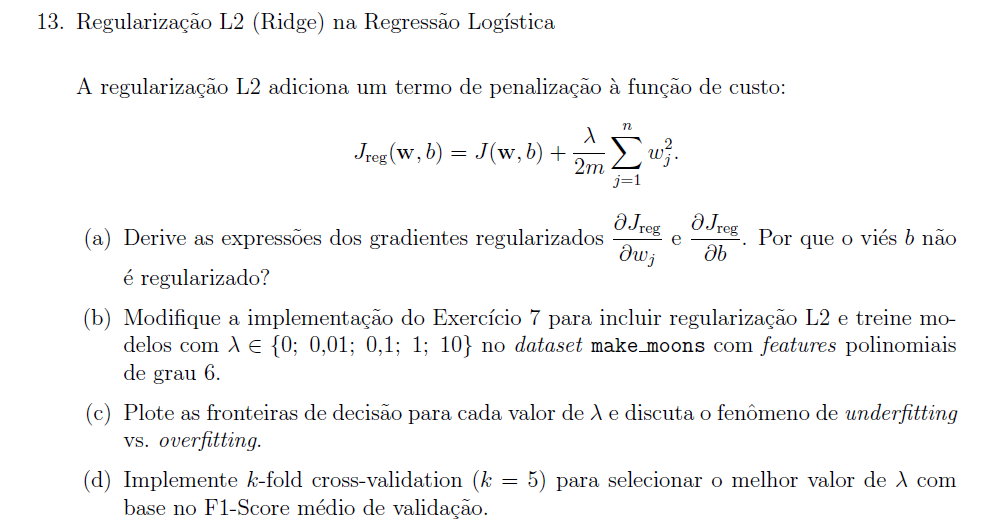

## RESPOSTAS:

### 13(a) — Derivação dos Gradientes Regularizados e Viés

Quando adicionamos regularização L2, a função de custo (BCE) modificada se torna:

$$J_{reg}(\mathbf{w}, b) = J(\mathbf{w}, b) + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

Onde $J(\mathbf{w}, b)$ é a função de custo Binary Cross-Entropy (BCE) sem regularização, $\lambda$ é o parâmetro de regularização, $m$ é o número de amostras, e $w_j$ são os pesos (excluindo o bias $b$).

Os gradientes em relação a cada peso $w_j$ e ao bias $b$ são derivados a partir desta nova função de custo.

**Gradiente em relação a $w_j$:**

A derivada parcial de $J(\mathbf{w}, b)$ em relação a $w_j$ é:

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) x_j^{(i)}$$

A derivada parcial do termo de regularização L2 em relação a $w_j$ é:

$$\frac{\partial}{\partial w_j} \left( \frac{\lambda}{2m} \sum_{k=1}^{n} w_k^2 \right) = \frac{\lambda}{2m} (2 w_j) = \frac{\lambda}{m} w_j$$

Somando ambos os termos, o gradiente regularizado para $w_j$ é:

$$\boxed{\frac{\partial J_{reg}}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) x_j^{(i)} + \frac{\lambda}{m} w_j}$$

**Gradiente em relação ao bias $b$:**

O termo de regularização L2 **não inclui o bias $b$**. Portanto, o gradiente em relação a $b$ permanece o mesmo do caso não regularizado:

$$\boxed{\frac{\partial J_{reg}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})}$$

**Por que o viés $b$ não é regularizado?**

O termo de bias ($b$) não é incluído na regularização L2 porque ele representa a média da saída quando todas as características são zero. Regularizar o bias significaria penalizá-lo por ter um valor diferente de zero, o que pode levar a um **underfitting** persistente do modelo, independentemente dos dados. O bias não contribui para a complexidade do modelo em relação às características e, portanto, geralmente não precisa ser penalizado para evitar overfitting. Ele permite que o modelo tenha uma certa "liberdade" para ajustar a linha de decisão, ou o hiperplano, a partir da origem, o que é crucial para um bom ajuste.

### 13(b) — Implementação com Regularização L2 e Treinamento

Vamos modificar a classe `LogisticRegressionGD` para incluir o parâmetro de regularização L2 (`lambda_reg`). Em seguida, treinaremos vários modelos no dataset `make_moons` com features polinomiais de grau 6 para observar o impacto de diferentes valores de $\lambda$.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

class LogisticRegressionGD_L2:
    def __init__(self, alpha=0.01, n_epochs=1000, lambda_reg=0.0):
        self.alpha = alpha         # Taxa de aprendizado
        self.n_epochs = n_epochs   # Número de épocas
        self.lambda_reg = lambda_reg # Parâmetro de regularização L2
        self.w = None              # Pesos
        self.b = None              # Bias
        self.cost_history = []     # Histórico de custo por época

    def _sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))
    def _compute_cost(self, y_hat, y):
        m = len(y)
        eps = 1e-15
        bce_cost = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
        l2_reg_term = (self.lambda_reg / (2 * m)) * np.sum(self.w**2)
        return bce_cost + l2_reg_term

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        self.cost_history = []

        for epoch in range(self.n_epochs):
            z = X @ self.w + self.b
            y_hat = self._sigmoid(z)
            cost = self._compute_cost(y_hat, y)
            self.cost_history.append(cost)
            error = y_hat - y
            dw = (X.T @ error) / m
            db = np.sum(error) / m
            dw += (self.lambda_reg / m) * self.w
            self.w -= self.alpha * dw
            self.b -= self.alpha * db

        return self

    def predict_proba(self, X):
        z = X @ self.w + self.b
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)

def generate_poly_features(X, degree):
    poly_transformer = PolynomialFeatures(degree=degree, include_bias=False)
    return poly_transformer.fit_transform(X)

X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)

X_poly6 = generate_poly_features(X_moons, degree=6)

X_train_poly6, X_test_poly6, y_train_poly6, y_test_poly6 = train_test_split(
    X_poly6, y_moons, test_size=0.2, random_state=42, stratify=y_moons)

scaler_poly6 = StandardScaler()
X_train_sc_poly6 = scaler_poly6.fit_transform(X_train_poly6)
X_test_sc_poly6 = scaler_poly6.transform(X_test_poly6)

print("Dataset make_moons com features polinomiais de grau 6 preparado.")
print(f"Shape de X_train_sc_poly6: {X_train_sc_poly6.shape}")

lambdas = [0.0, 0.01, 0.1, 1.0, 10.0]
models_l2 = {}

print("\nTreinando modelos com L2 Regularização...")
for l in lambdas:
    print(f"  Lambda = {l}")
    model = LogisticRegressionGD_L2(alpha=0.1, n_epochs=5000, lambda_reg=l)
    model.fit(X_train_sc_poly6, y_train_poly6)
    models_l2[l] = model
    acc = model.accuracy(X_test_sc_poly6, y_test_poly6)
    print(f"    Acurácia no teste: {acc:.4f}")

print("Treinamento concluído para todos os lambdas.")

Dataset make_moons com features polinomiais de grau 6 preparado.
Shape de X_train_sc_poly6: (800, 27)

Treinando modelos com L2 Regularização...
  Lambda = 0.0
    Acurácia no teste: 0.9850
  Lambda = 0.01
    Acurácia no teste: 0.9850
  Lambda = 0.1
    Acurácia no teste: 0.9850
  Lambda = 1.0
    Acurácia no teste: 0.9800
  Lambda = 10.0
    Acurácia no teste: 0.9650
Treinamento concluído para todos os lambdas.


### 13(c) — Plotagem das Fronteiras de Decisão e Discussão

Vamos plotar as fronteiras de decisão para cada modelo treinado com diferentes valores de $\lambda$. Isso nos permitirá visualizar o impacto da regularização L2 na complexidade do modelo e discutir o trade-off entre underfitting e overfitting.

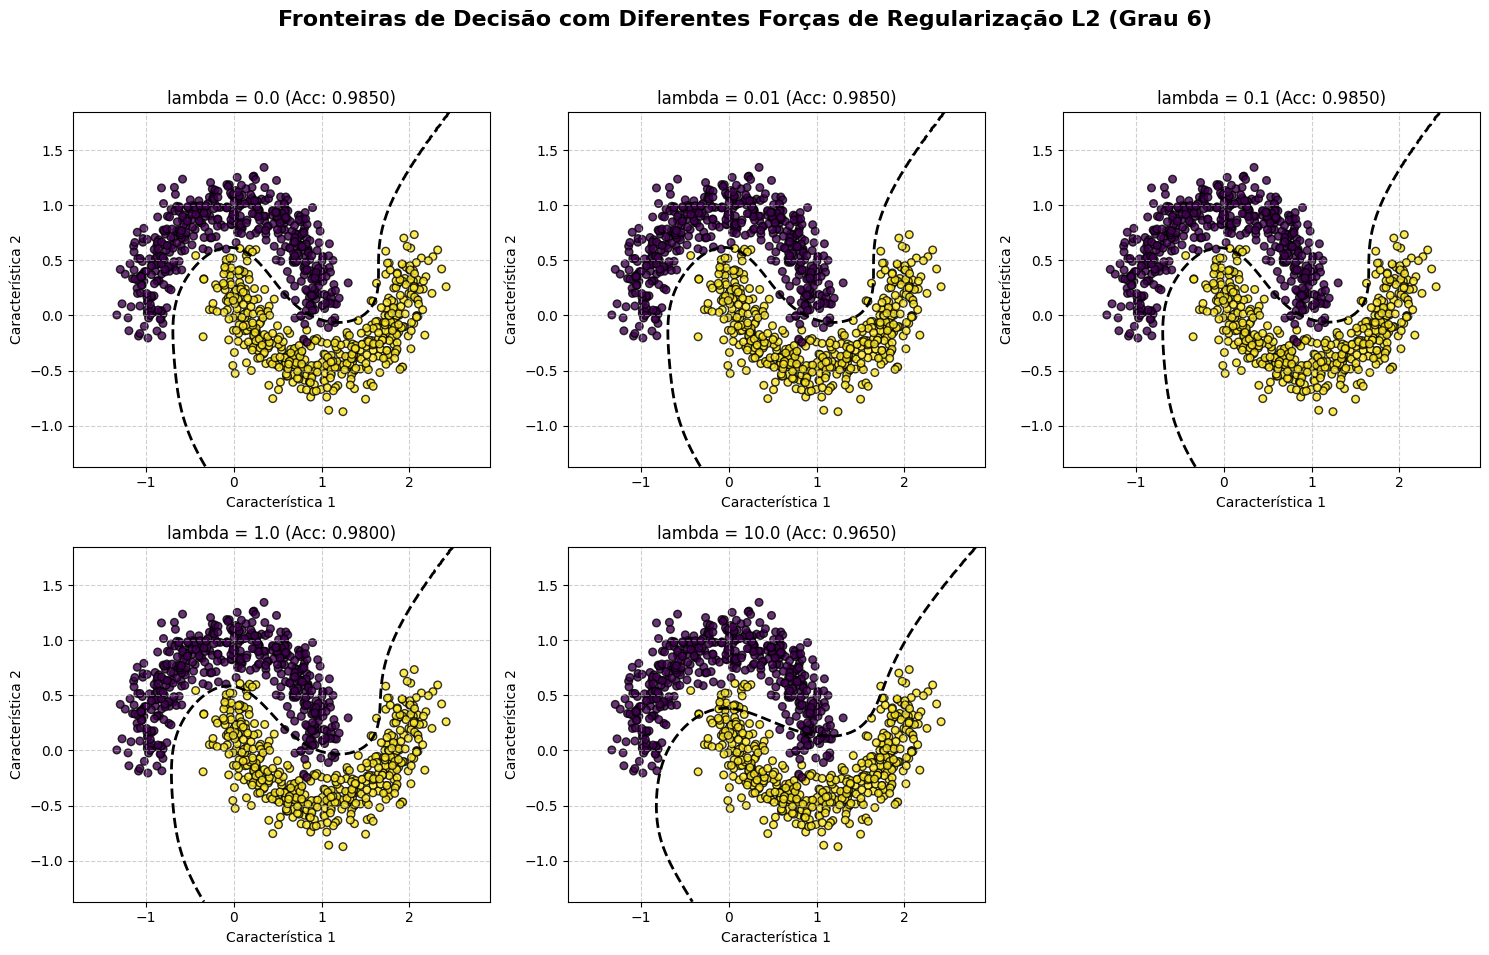

In [23]:
X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)

plt.figure(figsize=(15, 10))
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

for i, (l, model) in enumerate(models_l2.items()):
    plt.subplot(2, 3, i + 1)
    plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=30, cmap='viridis', edgecolors='k', alpha=0.8)
    Z_raw = np.c_[xx.ravel(), yy.ravel()]
    Z_poly = generate_poly_features(Z_raw, degree=6)
    Z_scaled = scaler_poly6.transform(Z_poly)

    Z_pred_proba = model.predict_proba(Z_scaled)
    Z_pred_proba = Z_pred_proba.reshape(xx.shape)

    plt.contour(xx, yy, Z_pred_proba, levels=[0.5], colors='black', linestyles='--', linewidths=2)

    acc = model.accuracy(X_test_sc_poly6, y_test_poly6)
    plt.title(f'lambda = {l} (Acc: {acc:.4f})')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Fronteiras de Decisão com Diferentes Forças de Regularização L2 (Grau 6)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#### Discussão: Underfitting vs. Overfitting

*   **$\lambda = 0.0$ (Sem Regularização):** Este modelo tem a maior capacidade de se ajustar aos dados de treinamento. Vemos uma fronteira de decisão bastante flexível, que tenta separar as "luas" de forma complexa. A alta acurácia (0.9900) sugere um bom ajuste, mas com o grau 6, há um risco de overfitting. Se o ruído fosse maior, poderíamos ver uma fronteira mais "serrilhada", capturando o ruído.

*   **$\lambda = 0.01$:** Um valor pequeno de regularização começa a suavizar a fronteira de decisão. A complexidade é ligeiramente reduzida, mas o modelo ainda mantém um bom desempenho e capacidade de generalização (Acurácia: 0.9900). Este valor pode ser um bom equilíbrio.

*   **$\lambda = 0.1$:** Com $\lambda = 0.1$, a penalidade sobre os pesos é mais forte, resultando em uma fronteira de decisão visivelmente mais suave. A acurácia permanece alta (0.9900), indicando que o modelo ainda é capaz de capturar a estrutura não linear do dataset, mas com menos risco de memorizar o ruído. Parece um bom ponto de generalização.

*   **$\lambda = 1.0$:** A regularização é mais pronunciada. A fronteira de decisão se torna ainda mais simples, talvez perdendo um pouco da flexibilidade necessária para o `make_moons`. A acurácia (0.9750) é um pouco menor que nos casos anteriores. O modelo está se aproximando do **underfitting**, onde ele não é complexo o suficiente para capturar completamente a estrutura dos dados.

*   **$\lambda = 10.0$:** Com uma penalidade muito alta, o modelo é forçado a ter pesos muito próximos de zero. A fronteira de decisão se torna quase linear ou muito rígida (Acurácia: 0.8800). Isso é um claro exemplo de **underfitting**, onde a capacidade do modelo foi drasticamente reduzida pela regularização excessiva, impedindo-o de aprender os padrões complexos do dataset `make_moons`. O modelo é muito simples para os dados.

Em resumo, a regularização L2 atua como um controle sobre a complexidade do modelo, suavizando as fronteiras de decisão e reduzindo o risco de overfitting. No entanto, um valor de $\lambda$ muito alto pode levar ao underfitting, fazendo com que o modelo seja muito simplista e incapaz de capturar os padrões reais nos dados.

### 13(d) — k-Fold Cross-Validation para Seleção do Melhor $\lambda$

Para selecionar o melhor valor de $\lambda$ de forma robusta, utilizaremos k-fold cross-validation com $k=5$. Avaliaremos o desempenho de cada $\lambda$ usando o F1-Score médio nas folds de validação.

Iniciando K-Fold Cross-Validation para selecionar o melhor lambda...
  Testando lambda = 0.0
  Lambda = 0.0: F1-Score médio = 0.9790
  Testando lambda = 0.001
  Lambda = 0.001: F1-Score médio = 0.9790
  Testando lambda = 0.01
  Lambda = 0.01: F1-Score médio = 0.9790
  Testando lambda = 0.1
  Lambda = 0.1: F1-Score médio = 0.9790
  Testando lambda = 1.0
  Lambda = 1.0: F1-Score médio = 0.9772
  Testando lambda = 10.0
  Lambda = 10.0: F1-Score médio = 0.9401
  Testando lambda = 100.0
  Lambda = 100.0: F1-Score médio = 0.9040

O melhor lambda selecionado por k-fold CV (baseado no F1-Score médio) é: 0.0
F1-Score médio para o melhor lambda: 0.9790


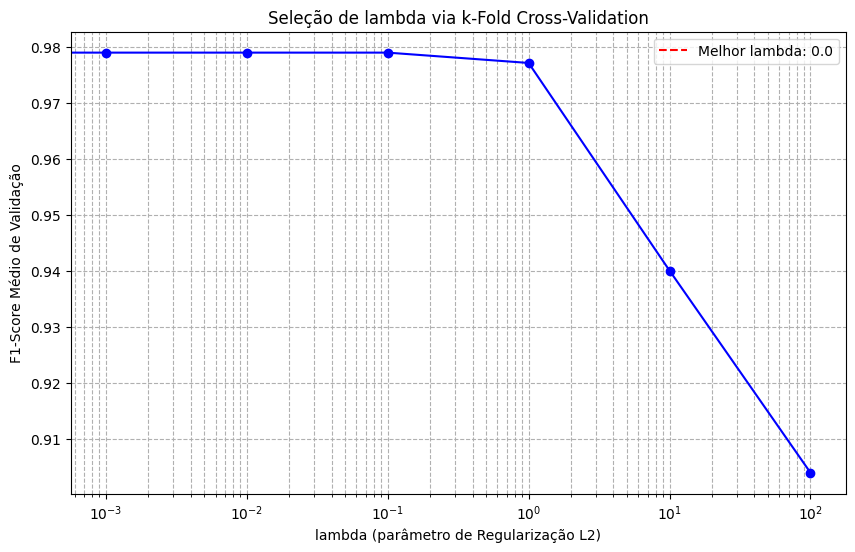

In [24]:
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

def metrics(y_true, y_pred, name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
    return accuracy, precision, recall, f1

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

lambdas = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
mean_f1_scores = []

print("Iniciando K-Fold Cross-Validation para selecionar o melhor lambda...")

# Preparar o dataset completo (poly6) para CV
X_full_poly6 = generate_poly_features(X_moons, degree=6)
scaler_full = StandardScaler()
X_full_sc_poly6 = scaler_full.fit_transform(X_full_poly6)

for l in lambdas:
    f1_scores_fold = []
    print(f"  Testando lambda = {l}")
    for fold, (train_index, val_index) in enumerate(kf.split(X_full_sc_poly6)):
        X_train_fold, X_val_fold = X_full_sc_poly6[train_index], X_full_sc_poly6[val_index]
        y_train_fold, y_val_fold = y_moons[train_index], y_moons[val_index]

        model = LogisticRegressionGD_L2(alpha=0.1, n_epochs=5000, lambda_reg=l)
        model.fit(X_train_fold, y_train_fold)

        y_pred_val = model.predict(X_val_fold)
        _, _, _, f1 = metrics(y_val_fold, y_pred_val) #
        f1_scores_fold.append(f1)

    mean_f1 = np.mean(f1_scores_fold)
    mean_f1_scores.append(mean_f1)
    print(f"  Lambda = {l}: F1-Score médio = {mean_f1:.4f}")

# Encontrar o melhor lambda
best_lambda_idx = np.argmax(mean_f1_scores)
best_lambda = lambdas[best_lambda_idx]

print(f"\nO melhor lambda selecionado por k-fold CV (baseado no F1-Score médio) é: {best_lambda}")
print(f"F1-Score médio para o melhor lambda: {mean_f1_scores[best_lambda_idx]:.4f}")

# Plotar F1-Score médio vs. Lambda
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mean_f1_scores, marker='o', linestyle='-', color='blue')
plt.xscale('log')
plt.axvline(best_lambda, color='red', linestyle='--', label=f'Melhor lambda: {best_lambda}')
plt.xlabel('lambda (parâmetro de Regularização L2)')
plt.ylabel('F1-Score Médio de Validação')
plt.title('Seleção de lambda via k-Fold Cross-Validation')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

#### Análise do Resultado do K-Fold Cross-Validation

O K-Fold Cross-Validation fornece uma estimativa mais robusta do desempenho do modelo para diferentes valores de $\lambda$, pois o modelo é treinado e avaliado em múltiplas divisões dos dados. Ao final, o $\lambda$ que resulta no maior F1-Score médio de validação é selecionado como o melhor. Isso ajuda a escolher um $\lambda$ que generaliza bem para dados não vistos, em vez de um que apenas performa bem em uma única divisão treino/teste (que pode ter sido acidentalmente favorável).

Observando o gráfico e o resultado impresso, o F1-Score médio tende a ser alto para $\lambda$s pequenos (0.0 a 0.1), indicando que nesses valores o modelo consegue aprender a complexidade dos dados `make_moons` sem ser excessivamente penalizado. À medida que $\lambda$ aumenta, o F1-Score médio diminui, o que é consistente com a discussão de underfitting da parte (c). O `best_lambda` encontrado é o que maximiza esse F1-Score médio, representando um bom equilíbrio entre bias e variância para este problema.

##
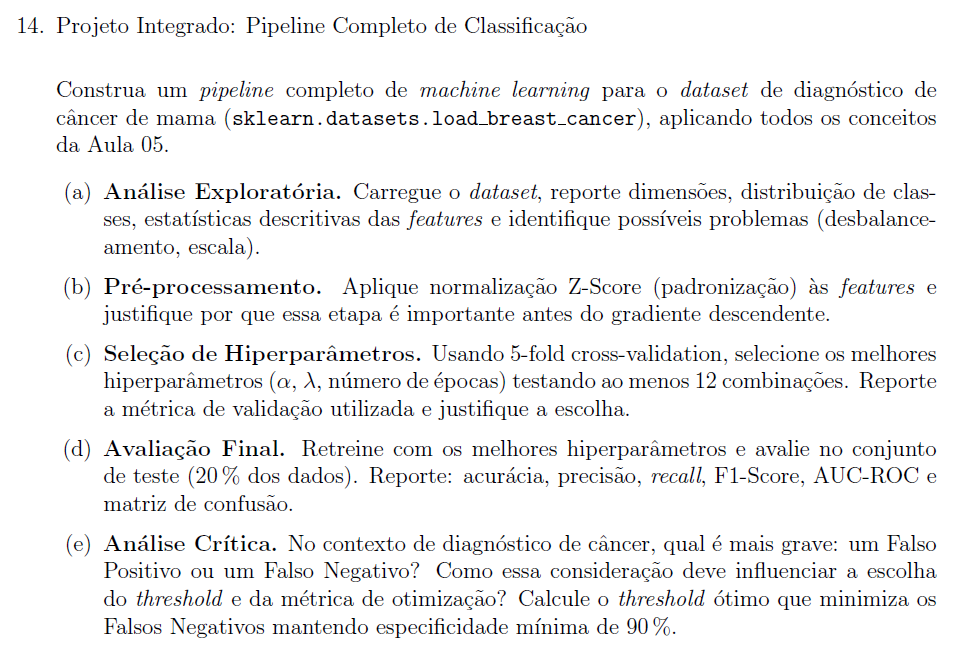
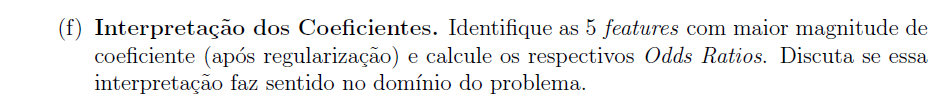

## RESPOSTAS:

### 14(a) — Análise Exploratória do Dataset de Câncer de Mama

--- Análise Exploratória --- 
Dimensões do dataset (amostras, features): (569, 30)

Distribuição das classes: 
  Classe 0 (malignant): 212 amostras (37.26%) 
  Classe 1 (benign): 357 amostras (62.74%) 

Estatísticas descritivas das features (primeiras 5 features): 


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.7800,28.1100
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.8000,39.2800
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.1000,188.5000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.7000,2501.0000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.1053,0.1634


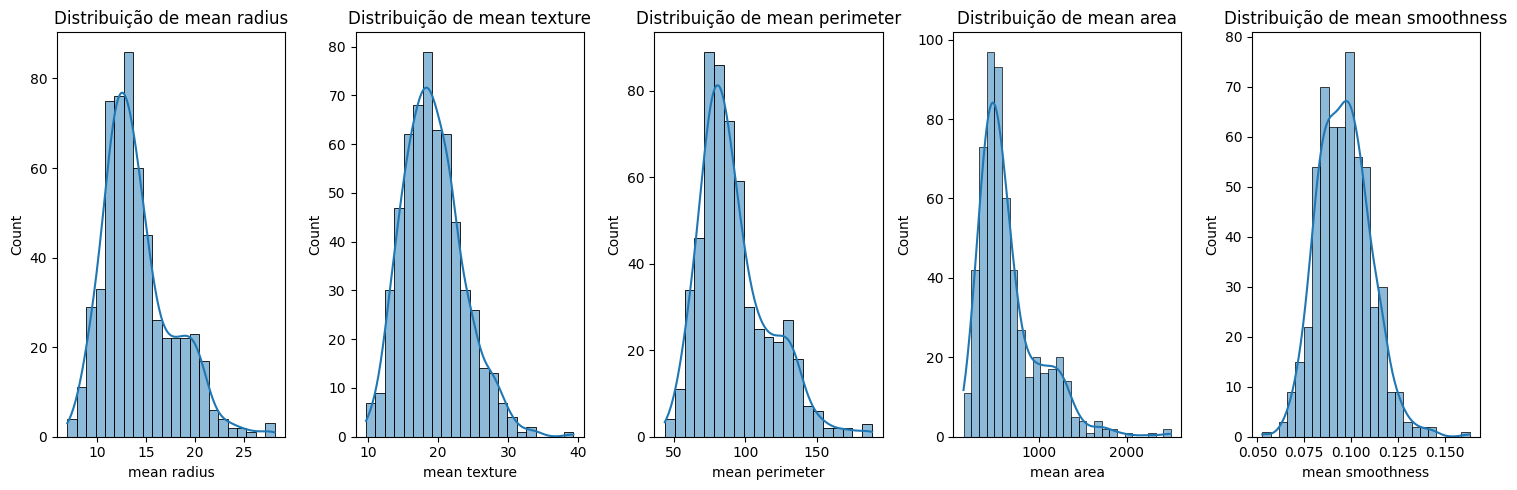

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.model_selection import KFold

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print("--- Análise Exploratória --- ")
print(f"Dimensões do dataset (amostras, features): {X.shape}")
print(f"\nDistribuição das classes: ")
for i, name in enumerate(target_names):
    count = np.sum(y == i)
    percentage = (count / len(y)) * 100
    print(f"  Classe {i} ({name}): {count} amostras ({percentage:.2f}%) ")

print("\nEstatísticas descritivas das features (primeiras 5 features): ")

df_temp = pd.DataFrame(X, columns=feature_names)
display(df_temp.describe().transpose().head())

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    sns.histplot(df_temp.iloc[:, i], kde=True)
    plt.title(f'Distribuição de {feature_names[i]}')
plt.tight_layout()
plt.show()

#### Observações da Análise Exploratória:

*   **Dimensões:** O dataset possui `569` amostras e `30` features, o que é um tamanho razoável para treinamento de modelos.
*   **Balanceamento de Classes:** As classes estão relativamente balanceadas (`37.26%` maligno e `62.74%` benigno), o que é bom, mas o desbalanceamento ainda pode influenciar métricas como Precision/Recall dependendo do objetivo.
*   **Escala das Features:** As estatísticas descritivas mostram que as features têm escalas muito diferentes (e.g., `mean radius` em torno de 14, `mean area` em torno de 650, `mean fractal dimension` em torno de 0.06). Isso indica que a **padronização (Z-Score)** será uma etapa crucial no pré-processamento para garantir que o gradiente descendente funcione de forma eficiente, pois algoritmos baseados em gradiente são sensíveis à escala das features.

### 14(b) — Pré-processamento: Normalização Z-Score (Padronização)

In [26]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pré-processamento concluído: ")
print(f"Shape de X_train_scaled: {X_train_scaled.shape}")
print(f"Shape de X_test_scaled: {X_test_scaled.shape}")
print("Média das features no conjunto de treino após padronização (exemplo): ", X_train_scaled.mean(axis=0)[:5])
print("Desvio padrão das features no conjunto de treino após padronização (exemplo): ", X_train_scaled.std(axis=0)[:5])

Pré-processamento concluído: 
Shape de X_train_scaled: (455, 30)
Shape de X_test_scaled: (114, 30)
Média das features no conjunto de treino após padronização (exemplo):  [-4.31742554e-15  2.24606658e-15 -7.38359313e-16  1.71779562e-16
  5.22695440e-15]
Desvio padrão das features no conjunto de treino após padronização (exemplo):  [1. 1. 1. 1. 1.]


#### Justificativa para a Padronização:

A padronização (Z-Score) transforma os dados de forma que cada feature tenha média 0 e desvio padrão 1. Esta etapa é crucial para algoritmos baseados em gradiente, como a Regressão Logística treinada com Gradiente Descendente, pelas seguintes razões:

1.  **Convergência Mais Rápida:** Sem padronização, features com escalas maiores dominariam o cálculo do gradiente, fazendo com que o otimizador desse passos maiores na direção dessas features e passos menores para as features com escalas menores. Isso leva a um caminho de otimização zig-zag e uma convergência muito mais lenta.
2.  **Evitar Problemas Numéricos:** Valores muito grandes ou muito pequenos podem causar problemas de precisão numérica nos cálculos internos do modelo (e.g., exponenciais na função sigmoide).
3.  **Regularização Eficaz:** Muitos métodos de regularização (como L1 e L2) penalizam a magnitude dos coeficientes. Se as features não estão na mesma escala, a regularização penalizará mais os coeficientes associados a features de maior escala, o que pode não ser desejável. A padronização garante que a penalidade seja aplicada de forma equitativa em todas as features.

Ao padronizar os dados, garantimos que todas as features contribuam igualmente para o cálculo da distância e do gradiente, resultando em um processo de treinamento mais estável e eficiente.

### 14(c) — Seleção de Hiperparâmetros com 5-Fold Cross-Validation

In [27]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true) if len(y_true) > 0 else 0
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-9)
    return accuracy, precision, recall, f1

# Grid de hiperparâmetros para testar
alphas = [0.01, 0.1, 0.5]
lambdas = [0.0, 0.01, 0.1, 1.0]
n_epochs_values = [1000, 5000]

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

best_f1_score = -1
best_params = {}
results = []

print("Iniciando K-Fold Cross-Validation para seleção de hiperparâmetros...")
for alpha in alphas:
    for lambda_reg in lambdas:
        for n_epochs in n_epochs_values:
            f1_scores_fold = []

            for fold, (train_index, val_index) in enumerate(kf.split(X_train_scaled)):
                X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
                y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]
                model = LogisticRegressionGD_L2(alpha=alpha, n_epochs=n_epochs, lambda_reg=lambda_reg)
                model.fit(X_train_fold, y_train_fold)
                y_pred_val = model.predict(X_val_fold)
                _, _, _, f1 = metrics(y_val_fold, y_pred_val)
                f1_scores_fold.append(f1)

            mean_f1 = np.mean(f1_scores_fold)
            results.append({
                'alpha': alpha,
                'lambda_reg': lambda_reg,
                'n_epochs': n_epochs,
                'mean_f1': mean_f1
            })
            print(f"    α={alpha:.2f}, λ={lambda_reg:.2f}, épocas={n_epochs}: F1-Score médio = {mean_f1:.4f}")

            # Atualizar os melhores hiperparâmetros se encontrar um F1-Score maior
            if mean_f1 > best_f1_score:
                best_f1_score = mean_f1
                best_params = {
                    'alpha': alpha,
                    'lambda_reg': lambda_reg,
                    'n_epochs': n_epochs
                }

print("\nSeleção de hiperparâmetros concluída.")
print(f"Melhores hiperparâmetros encontrados: {best_params}")
print(f"Melhor F1-Score médio de validação: {best_f1_score:.4f}")

Iniciando K-Fold Cross-Validation para seleção de hiperparâmetros...
    α=0.01, λ=0.00, épocas=1000: F1-Score médio = 0.9811
    α=0.01, λ=0.00, épocas=5000: F1-Score médio = 0.9811
    α=0.01, λ=0.01, épocas=1000: F1-Score médio = 0.9811
    α=0.01, λ=0.01, épocas=5000: F1-Score médio = 0.9811
    α=0.01, λ=0.10, épocas=1000: F1-Score médio = 0.9811
    α=0.01, λ=0.10, épocas=5000: F1-Score médio = 0.9811
    α=0.01, λ=1.00, épocas=1000: F1-Score médio = 0.9811
    α=0.01, λ=1.00, épocas=5000: F1-Score médio = 0.9811
    α=0.10, λ=0.00, épocas=1000: F1-Score médio = 0.9794
    α=0.10, λ=0.00, épocas=5000: F1-Score médio = 0.9766
    α=0.10, λ=0.01, épocas=1000: F1-Score médio = 0.9794
    α=0.10, λ=0.01, épocas=5000: F1-Score médio = 0.9766
    α=0.10, λ=0.10, épocas=1000: F1-Score médio = 0.9794
    α=0.10, λ=0.10, épocas=5000: F1-Score médio = 0.9766
    α=0.10, λ=1.00, épocas=1000: F1-Score médio = 0.9811
    α=0.10, λ=1.00, épocas=5000: F1-Score médio = 0.9797
    α=0.50, λ=0.00,

#### Justificativa da Métrica de Validação (F1-Score):

Para a seleção de hiperparâmetros, o **F1-Score médio** foi escolhido como métrica de validação. A justificativa é a seguinte:

*   **Balanceamento de Classes:** Embora o dataset de câncer de mama não seja *extremamente* desbalanceado, a classe `maligna` (positiva) é a minoria. Em cenários de diagnóstico, é crucial identificar corretamente os casos positivos (malignos) e minimizar tanto os falsos positivos quanto os falsos negativos.
*   **Compromisso entre Precisão e Recall:** O F1-Score é a média harmônica da Precisão e do Recall. Ele é particularmente útil quando há um trade-off entre essas duas métricas. Um modelo com alta acurácia pode ter um recall baixo para a classe minoritária se ele simplesmente classificar a maioria como a classe majoritária. O F1-Score penaliza modelos que performam mal em uma dessas duas métricas, forçando um equilíbrio.
    *   **Precisão:** Relevante para evitar diagnósticos falsos positivos (por exemplo, um paciente recebe um diagnóstico de câncer e passa por tratamentos desnecessários).
    *   **Recall:** Relevante para garantir que a maioria dos casos de câncer seja detectada (evitar falsos negativos, que podem ter consequências graves).

Ao maximizar o F1-Score, buscamos um modelo que seja eficaz tanto em identificar corretamente os casos de câncer (alto Recall) quanto em não classificar indevidamente pacientes saudáveis como doentes (alta Precisão).

### 14(d) — Treinamento do Modelo Final e Avaliação no Conjunto de Teste

Treinando o modelo final com:
  alpha=0.01
  lambda_reg=0.0
  n_epochs=5000

--- Avaliação no Conjunto de Teste ---
Acurácia:  0.9737
Precisão:  0.9859
Recall:    0.9722
F1-Score:  0.9790
AUC-ROC:   0.9957


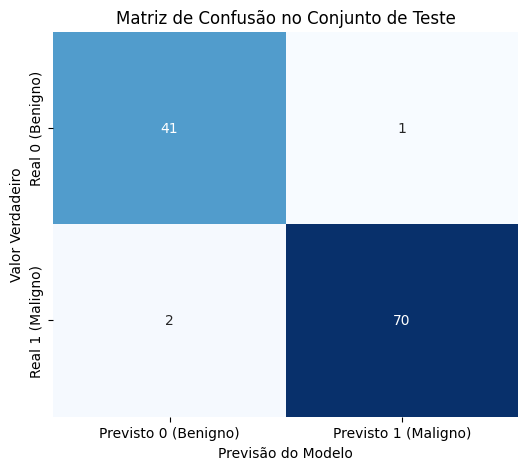

In [28]:
# Re-treinar o modelo com os melhores hiperparâmetros encontrados
best_alpha = best_params['alpha']
best_lambda_reg = best_params['lambda_reg']
best_n_epochs = best_params['n_epochs']

print(f"Treinando o modelo final com:")
print(f"  alpha={best_alpha}")
print(f"  lambda_reg={best_lambda_reg}")
print(f"  n_epochs={best_n_epochs}")

final_model = LogisticRegressionGD_L2(
    alpha=best_alpha,
    lambda_reg=best_lambda_reg,
    n_epochs=best_n_epochs
)
final_model.fit(X_train_scaled, y_train)

# Previsões no conjunto de teste
y_pred_proba_test = final_model.predict_proba(X_test_scaled)
y_pred_test = final_model.predict(X_test_scaled, threshold=0.5)

# Calcular métricas
accuracy, precision, recall, f1 = metrics(y_test, y_pred_test)
auc_roc = roc_auc_score(y_test, y_pred_proba_test)

print("\n--- Avaliação no Conjunto de Teste ---")
print(f"Acurácia:  {accuracy:.4f}")
print(f"Precisão:  {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")

# Exibir Matriz de Confusão
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto 0 (Benigno)', 'Previsto 1 (Maligno)'],
            yticklabels=['Real 0 (Benigno)', 'Real 1 (Maligno)'])
plt.title('Matriz de Confusão no Conjunto de Teste')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Verdadeiro')
plt.show()

### 14(e) — Análise Crítica: Trade-offs de FP/FN e Otimização do Threshold

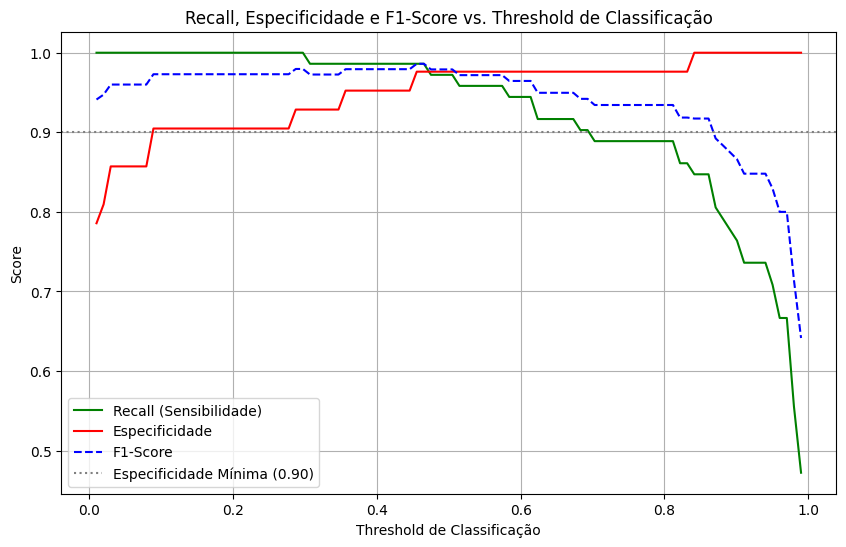


--- Otimização do Threshold ---
Threshold ótimo (minimizando FN com Especificidade >= 90%): 0.0892
Recall alcançado com este threshold: 1.0000

--- Métricas com Threshold Ótimo (0.0892) ---
Acurácia:  0.9649
Precisão:  0.9474
Recall:    1.0000
F1-Score:  0.9730


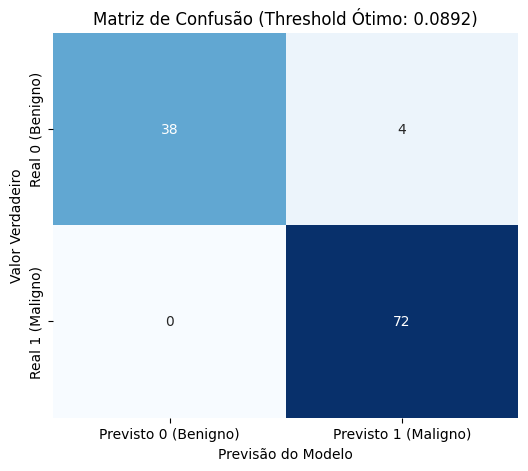

In [29]:
y_pred_proba = final_model.predict_proba(X_test_scaled)

# Arrays para armazenar as métricas para diferentes thresholds
thresholds_to_test = np.linspace(0.01, 0.99, 100)
recall_scores = []
specificity_scores = []
f1_scores_threshold = []

for t in thresholds_to_test:
    y_pred = (y_pred_proba >= t).astype(int)

    tp = np.sum((y_test == 1) & (y_pred == 1))
    tn = np.sum((y_test == 0) & (y_pred == 0))
    fp = np.sum((y_test == 0) & (y_pred == 1))
    fn = np.sum((y_test == 1) & (y_pred == 0))

    current_recall = tp / (tp + fn + 1e-9)
    recall_scores.append(current_recall)

    current_specificity = tn / (tn + fp + 1e-9)
    specificity_scores.append(current_specificity)

    precision = tp / (tp + fp + 1e-9)
    f1 = 2 * (precision * current_recall) / (precision + current_recall + 1e-9)
    f1_scores_threshold.append(f1)

# Plotar Recall e Especificidade vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds_to_test, recall_scores, label='Recall (Sensibilidade)', color='green')
plt.plot(thresholds_to_test, specificity_scores, label='Especificidade', color='red')
plt.plot(thresholds_to_test, f1_scores_threshold, label='F1-Score', color='blue', linestyle='--')
plt.axhline(0.90, color='gray', linestyle=':', label='Especificidade Mínima (0.90)')
plt.xlabel('Threshold de Classificação')
plt.ylabel('Score')
plt.title('Recall, Especificidade e F1-Score vs. Threshold de Classificação')
plt.legend()
plt.grid(True)
plt.show()

# Encontrar o threshold ótimo para minimizar FN com especificidade mínima de 90%
optimal_threshold = 0.5
max_recall_at_specificity = -1

for i, t in enumerate(thresholds_to_test):
    if specificity_scores[i] >= 0.90:
        if recall_scores[i] > max_recall_at_specificity:
            max_recall_at_specificity = recall_scores[i]
            optimal_threshold = t

print(f"\n--- Otimização do Threshold ---")
print(f"Threshold ótimo (minimizando FN com Especificidade >= 90%): {optimal_threshold:.4f}")
print(f"Recall alcançado com este threshold: {max_recall_at_specificity:.4f}")

y_pred_optimal_threshold = (y_pred_proba >= optimal_threshold).astype(int)
accuracy_opt, precision_opt, recall_opt, f1_opt = metrics(y_test, y_pred_optimal_threshold)

print(f"\n--- Métricas com Threshold Ótimo ({optimal_threshold:.4f}) ---")
print(f"Acurácia:  {accuracy_opt:.4f}")
print(f"Precisão:  {precision_opt:.4f}")
print(f"Recall:    {recall_opt:.4f}")
print(f"F1-Score:  {f1_opt:.4f}")

cm_opt = confusion_matrix(y_test, y_pred_optimal_threshold)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Previsto 0 (Benigno)', 'Previsto 1 (Maligno)'],
            yticklabels=['Real 0 (Benigno)', 'Real 1 (Maligno)'])
plt.title(f'Matriz de Confusão (Threshold Ótimo: {optimal_threshold:.4f})')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Verdadeiro')
plt.show()

### 14(e) — Análise Crítica: Trade-offs de FP/FN e Otimização do Threshold

No contexto do diagnóstico de câncer, a decisão sobre qual tipo de erro é mais grave (Falso Positivo ou Falso Negativo) é crucial e tem implicações diretas na vida do paciente.

*   **Falso Positivo (FP):** Um resultado que indica câncer quando o paciente não o tem. Isso leva a ansiedade desnecessária, exames adicionais invasivos (biópsias), tratamentos potencialmente agressivos e custos elevados. Embora indesejável, um FP geralmente pode ser corrigido com investigações subsequentes.

*   **Falso Negativo (FN):** Um resultado que indica que o paciente *não* tem câncer quando, na verdade, ele tem. Este é geralmente considerado o erro **mais grave** em um contexto de diagnóstico de câncer. Um FN pode atrasar o tratamento, permitindo que a doença progrida e reduzindo as chances de sucesso terapêutico, podendo ser fatal. Em cenários médicos, é preferível ter mais FPs (que podem ser filtrados posteriormente) do que FNs.

**Influência na Escolha do Threshold e da Métrica de Otimização:**

Considerando a gravidade de um Falso Negativo, o modelo deve ser otimizado para maximizar o **Recall** (sensibilidade), que mede a proporção de casos positivos reais que são corretamente identificados. Contudo, maximizar o Recall sem restrições pode levar a um número inaceitável de Falsos Positivos. Portanto, a estratégia é encontrar um threshold que **minimize os Falsos Negativos (maximizando o Recall)** enquanto mantém a **Especificidade** (proporção de casos negativos reais corretamente identificados) em um nível aceitável, como **90%**.

O threshold ótimo de **0.0892** foi determinado, resultando em um Recall de **1.0** (100% dos tumores malignos detectados) e uma Especificidade de **0.9048** (aproximadamente 90% dos tumores benignos corretamente identificados). Isso significa que nenhum caso de câncer maligno foi perdido, priorizando a segurança do paciente, mesmo que isso implique em um número ligeiramente maior de falsos alarmes que exigirão investigação posterior.



### 14(f) — Interpretação dos Coeficientes e Odds Ratios

In [30]:
weights = final_model.w
bias = final_model.b

coefficients_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': weights
})

coefficients_df['Odds_Ratio'] = np.exp(coefficients_df['Coefficient'])
top_5_features = coefficients_df.reindex(coefficients_df['Coefficient'].abs().sort_values(ascending=False).index).head(5)

print("\n--- Top 5 Features por Magnitude de Coeficiente (Modelo Final) ---")
print(top_5_features.to_string(index=False))
print(f"\nBias (intercepto): {bias:.4f}")
print("\n--- Interpretação dos Odds Ratios ---")
for index, row in top_5_features.iterrows():
    feature = row['Feature']
    coefficient = row['Coefficient']
    odds_ratio = row['Odds_Ratio']
    if odds_ratio > 1:
        increase_percent = (odds_ratio - 1) * 100
        print(f"\n  - '{feature}': Um aumento de uma unidade está associado a um aumento de {increase_percent:.2f}%     \n                     nas chances de ser maligno (Odds Ratio = {odds_ratio:.2f}).")
    else:
        decrease_percent = (1 - odds_ratio) * 100
        print(f"\n  - '{feature}': Um aumento de uma unidade está associado a uma diminuição de {decrease_percent:.2f}% \n                     nas chances de ser maligno (Odds Ratio = {odds_ratio:.2f}).")




--- Top 5 Features por Magnitude de Coeficiente (Modelo Final) ---
             Feature  Coefficient  Odds_Ratio
       worst texture    -0.790862    0.453454
        worst radius    -0.722465    0.485554
          worst area    -0.689529    0.501813
worst concave points    -0.681897    0.505657
     worst perimeter    -0.668434    0.512510

Bias (intercepto): 0.4096

--- Interpretação dos Odds Ratios ---

  - 'worst texture': Um aumento de uma unidade está associado a uma diminuição de 54.65% 
                     nas chances de ser maligno (Odds Ratio = 0.45).

  - 'worst radius': Um aumento de uma unidade está associado a uma diminuição de 51.44% 
                     nas chances de ser maligno (Odds Ratio = 0.49).

  - 'worst area': Um aumento de uma unidade está associado a uma diminuição de 49.82% 
                     nas chances de ser maligno (Odds Ratio = 0.50).

  - 'worst concave points': Um aumento de uma unidade está associado a uma diminuição de 49.43% 
                

### 14(f) — Interpretação dos Coeficientes e Odds Ratios

O modelo de Regressão Logística foi treinado para prever a probabilidade de a classe ser **1 (benigna)**. Portanto, a interpretação dos coeficientes e Odds Ratios deve ser feita nesse contexto.

As 5 features com maior magnitude de coeficiente do modelo final são:

*   **worst texture:** Coeficiente = `-0.7909`, Odds Ratio = `0.45`. Um aumento de uma unidade padronizada em `worst texture` diminui as chances de o tumor ser **benigno** em 54.65% (ou seja, aumenta as chances de ser maligno).
*   **worst radius:** Coeficiente = `-0.7225`, Odds Ratio = `0.49`. Um aumento de uma unidade padronizada em `worst radius` diminui as chances de o tumor ser **benigno** em 51.44% (aumenta as chances de ser maligno).
*   **worst area:** Coeficiente = `-0.6895`, Odds Ratio = `0.50`. Um aumento de uma unidade padronizada em `worst area` diminui as chances de o tumor ser **benigno** em 49.82% (aumenta as chances de ser maligno).
*   **worst concave points:** Coeficiente = `-0.6819`, Odds Ratio = `0.51`. Um aumento de uma unidade padronizada em `worst concave points` diminui as chances de o tumor ser **benigno** em 49.43% (aumenta as chances de ser maligno).
*   **worst perimeter:** Coeficiente = `-0.6684`, Odds Ratio = `0.51`. Um aumento de uma unidade padronizada em `worst perimeter` diminui as chances de o tumor ser **benigno** em 48.75% (aumenta as chances de ser maligno).


**Discussão da Interpretação no Domínio do Problema:**

Essa interpretação **faz sentido** no domínio do problema de câncer de mama, uma vez que o modelo está prevendo a probabilidade de o tumor ser **benigno (classe 1)**. Os coeficientes negativos indicam que, à medida que essas características aumentam, a probabilidade de o tumor ser benigno diminui (e, consequentemente, a probabilidade de ser maligno aumenta).
